In [ ]:
# Setting up
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import Normalize
from matplotlib import cm
import matplotlib as mpl

import numpy as np
import pandas as pd
import random

import scipy
import sys
import os.path
sys.path.insert(1, '../scripts/03_analytical_prediction')
from tpc_functions_oo import *
tpc_object = tpc_functions()


import tskit
from matplotlib.lines import Line2D
datadir = "../data/"


# Track data files that are used for figures and write their paths to a text file at the end
_accessed = set()
def _track(fn):
    def wrapped(path, *a, **k):
        _accessed.add(os.path.abspath(path))
        return fn(path, *a, **k)
    return wrapped
pd.read_csv = _track(pd.read_csv)
np.load     = _track(np.load)
tskit.load  = _track(tskit.load)

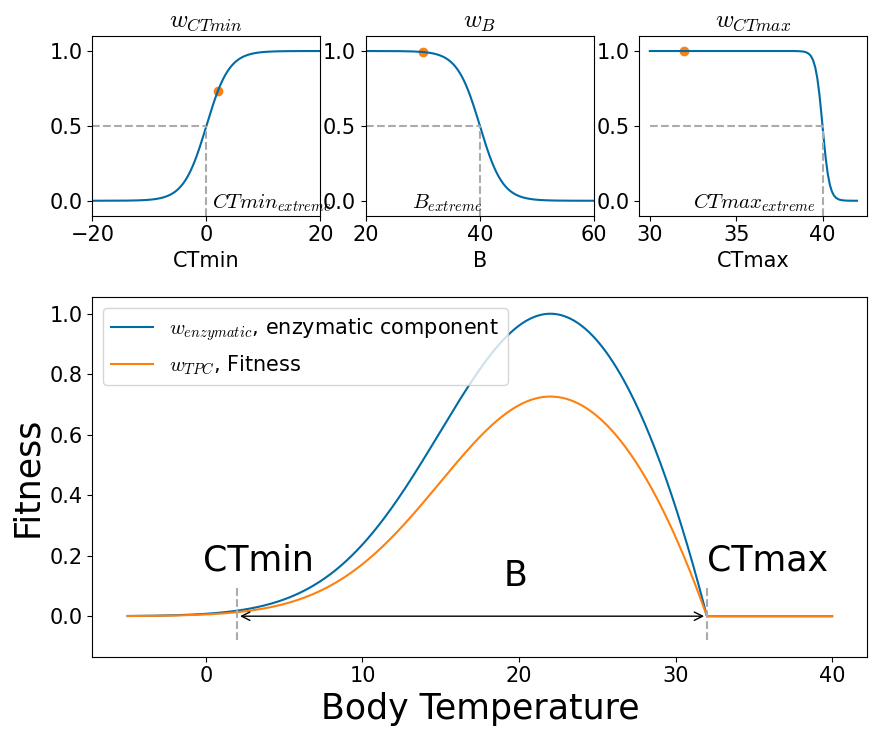

In [ ]:
# Figure S1
plt.rcParams.update({'font.size': 15})
B_list = np.linspace(20, 60, 300)
CTmin_list = np.linspace(-20, 20, 400)
CTmax_list = np.linspace(30, 42, 100)

Tlist = np.linspace(-5, 40, 400)
# parameters for TPC component
B = 30
CTmin = 2
CTmax = B + CTmin 


# tableau T10 colorblind color list
t10_colors = ['#006BA4', '#FF800E', '#ABABAB', '#595959', '#5F9ED1', '#C85200', '#898989', '#A2C8EC', '#FFBC79', '#CFCFCF']
fig = plt.figure(figsize = (10,7))
subfigs = fig.subfigures(nrows=2, ncols=1, height_ratios=[1,2])
plt.rcParams.update({'font.size': 15})

# fitness components
axes = subfigs[0].subplots(nrows=1, ncols=3)
for ax in axes:
    ax.set_ylim((-0.1, 1.1))

# w_CTmin
axes[0].set_xlim((CTmin_list[0], CTmin_list[-1]))
axes[0].plot(CTmin_list, tpc_object.w_CTmin(CTmin=CTmin_list), color=t10_colors[0])
axes[0].set_title(r"$w_{CTmin}$")
axes[0].set_xlabel("CTmin")
axes[0].scatter(CTmin, tpc_object.w_CTmin(CTmin=CTmin), color=t10_colors[1])
axes[0].hlines(0.5, xmin=CTmin_list[0], xmax=tpc_object.CTmin_critical, color=t10_colors[2], linestyle='--')
axes[0].vlines(tpc_object.CTmin_critical, ymin=-0.1, ymax=0.5, color=t10_colors[2], linestyle='--')
axes[0].text(1, -0.05, r"$CTmin_{extreme}$", fontsize=15)

# w_B
axes[1].set_xlim((B_list[0], B_list[-1]))
axes[1].plot(B_list, tpc_object.w_B(B=B_list), color=t10_colors[0])
axes[1].set_title(r"$w_{B}$")
axes[1].set_xlabel("B")
axes[1].scatter(B, tpc_object.w_B(B=B), color=t10_colors[1])
axes[1].hlines(0.5, xmin=B_list[0], xmax=tpc_object.B_critical, color=t10_colors[2], linestyle='--')
axes[1].vlines(tpc_object.B_critical, ymin=-0.1, ymax=0.5, linestyle='--', color=t10_colors[2])
axes[1].text(28, -0.05, r"$B_{extreme}$", fontsize=15)

# w_CTmax
axes[2].plot(CTmax_list, tpc_object.w_CTmax(CTmax=CTmax_list), color=t10_colors[0])
axes[2].set_title(r"$w_{CTmax}$")
axes[2].set_xlabel("CTmax")
axes[2].scatter(CTmax, tpc_object.w_CTmax(CTmax=CTmax), color=t10_colors[1])
axes[2].hlines(0.5, xmin=CTmax_list[0], xmax=tpc_object.CTmax_critical, color=t10_colors[2], linestyle='--')
axes[2].vlines(tpc_object.CTmax_critical, ymin=-0.1, ymax=0.5, linestyle='--', color=t10_colors[2])
axes[2].text(32.5, -0.05, r"$CTmax_{extreme}$", fontsize=15)

# An example enzymatic component and overall fitness (as a function of T)
ax0 = subfigs[1].subplots(nrows=1, ncols=1)
enzymatic_component = tpc_object.w_enzymatic(CTmin=CTmin, B=B, T=Tlist)
ax0.plot(Tlist, enzymatic_component, label=r"$w_{enzymatic}$, enzymatic component", color=t10_colors[0])
ax0.plot(Tlist, tpc_object.w_TPC(CTmin=CTmin, B=B, T=Tlist), label=r"$w_{TPC}$, Fitness", color=t10_colors[1])
ax0.vlines(CTmin, ymin=-0.08, ymax=0.1, linestyle='--', color=t10_colors[2])
ax0.vlines(CTmax, ymin=-0.08, ymax=0.1, linestyle='--', color=t10_colors[2])
ax0.annotate("", xytext=(CTmin, 0), xy=(CTmax, 0),
            arrowprops=dict(arrowstyle="<->"), color=t10_colors[2])
ax0.set_ylabel("Fitness", fontsize=25)
ax0.set_xlabel("Body Temperature", fontsize=25)
ax0.legend()
ax0.text(-0.2, 0.15, "CTmin", fontsize=25)
ax0.text(19, 0.1, "B", fontsize=25)
ax0.text(32, 0.15, "CTmax", fontsize=25)


fig.savefig("../figures/fitness_components_1d.pdf", bbox_inches='tight')

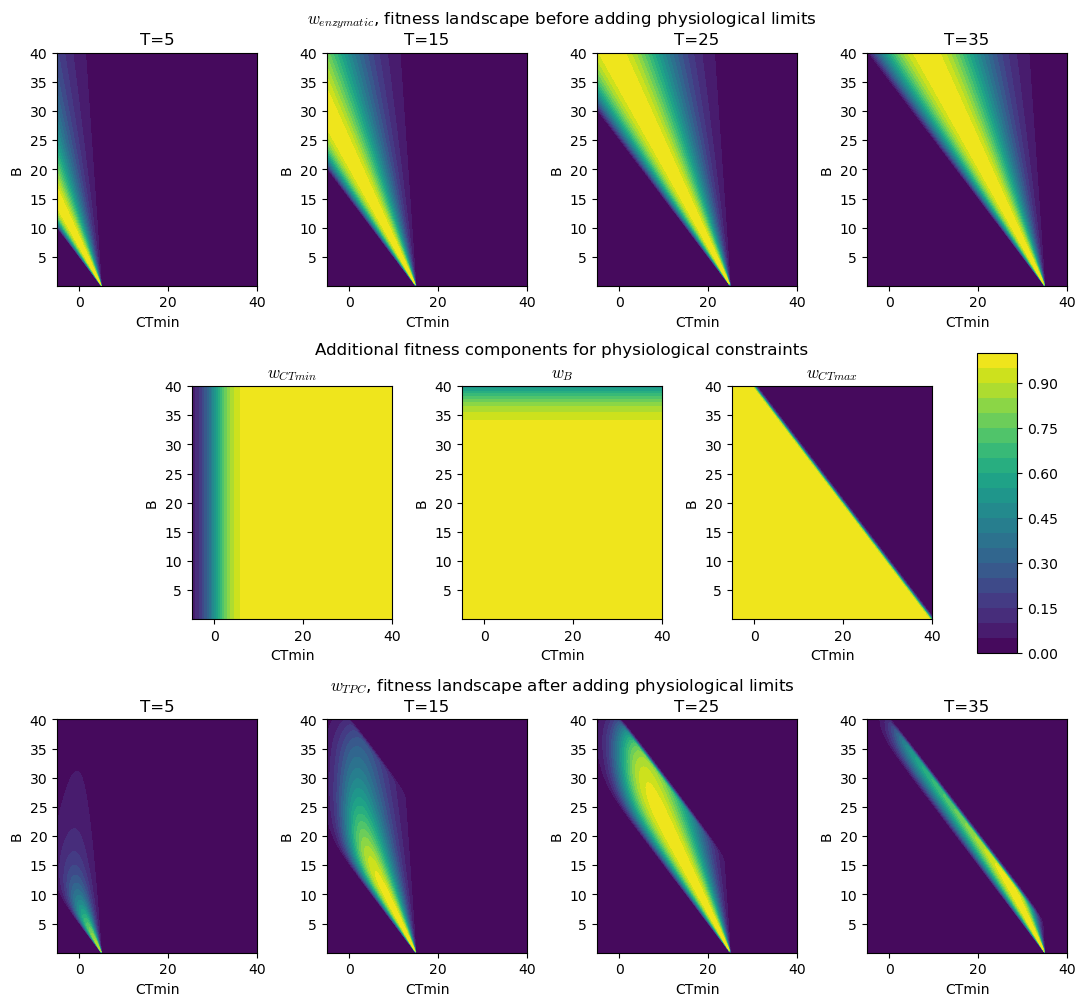

In [ ]:
# Figure S2 
fig = plt.figure(figsize=(10,10))
subfigs = fig.subfigures(nrows=3, ncols=1)
width = 0.2
space = 0.07
bottom = 0.15
height = 0.7

CTmin_list = np.linspace(-2, 40, 100)
B_list = np.linspace(0.01, 40, 100)

# Generate fitness landscape for 4 temperatures 
Tlist = [5, 15, 25, 35]
B_list = np.linspace(1e-3, 40, 300)
CTmin_list = np.linspace(-5, 40, 450)
CTmax_list = np.linspace(-5, 50, 500) # purely for plotting fitness component for CTmax
[CTmin_grid, B_grid] = np.meshgrid(CTmin_list, B_list)
CTmax_grid = CTmin_grid + B_grid

levels = np.linspace(0, 1, 21)

    
# Make contours 
C1_contour = tpc_object.w_CTmin(CTmin=CTmin_grid)
C2_contour = tpc_object.w_B(B=B_grid)
C3_contour = tpc_object.w_CTmax(CTmax=CTmax_grid)
components = [C1_contour, C2_contour, C3_contour]
components_titles = [r"$w_{CTmin}$", r"$w_{B}$", r"$w_{CTmax}$"]

plt.rcParams.update({'font.size': 10})
# Top row
subfigs[0].suptitle(r"$w_{enzymatic}$, fitness landscape before adding physiological limits")
left_space = (1 - width * len(Tlist) - space * (len(Tlist)-1)) / 2
for i, T in enumerate(Tlist):
    P_contour = tpc_object.w_enzymatic(CTmin=CTmin_list, B=B_list, T=T)
    ax = subfigs[0].add_axes([left_space + (width + space) * i, bottom, width, height])
    ax.contourf(CTmin_grid, B_grid, P_contour, levels=levels)
    ax.set_title(f"T={T}")
    ax.set_xlabel("CTmin")
    ax.set_ylabel("B")

# Middle row
subfigs[1].suptitle("Additional fitness components for physiological constraints")
left_space = (1 - width * len(components) - space * (len(components)-1)) / 2
for i, contour in enumerate(components):
    ax = subfigs[1].add_axes([left_space + (width + space) * i, bottom, width, height])
    ax.contourf(CTmin_grid, B_grid, contour, levels=levels)
    ax.set_title(components_titles[i])
    ax.set_xlabel("CTmin")
    ax.set_ylabel("B")

# Last row
subfigs[2].suptitle(r"$w_{TPC}$, fitness landscape after adding physiological limits")
left_space = (1 - width * len(Tlist) - space * (len(Tlist)-1)) / 2
for i, T in enumerate(Tlist):
    W_contour = tpc_object.w_TPC(CTmin=CTmin_list, B=B_list, T=T)
    ax = subfigs[2].add_axes([left_space + (width + space) * i, bottom, width, height])
    contour = ax.contourf(CTmin_grid, B_grid, W_contour, levels=levels)
    ax.set_title(f"T={T}")
    ax.set_xlabel("CTmin")
    ax.set_ylabel("B")
cbar_ax = fig.add_axes([0.915, 0.35, 0.04, 0.3])
cbar = fig.colorbar(contour, cax=cbar_ax, extend='max')
fig.savefig("../figures/fitness_components_2d.pdf", bbox_inches='tight')

muT=5, sigmaT=1
muT=5, sigmaT=3
muT=20, sigmaT=1
muT=20, sigmaT=3
muT=35, sigmaT=1
muT=35, sigmaT=3


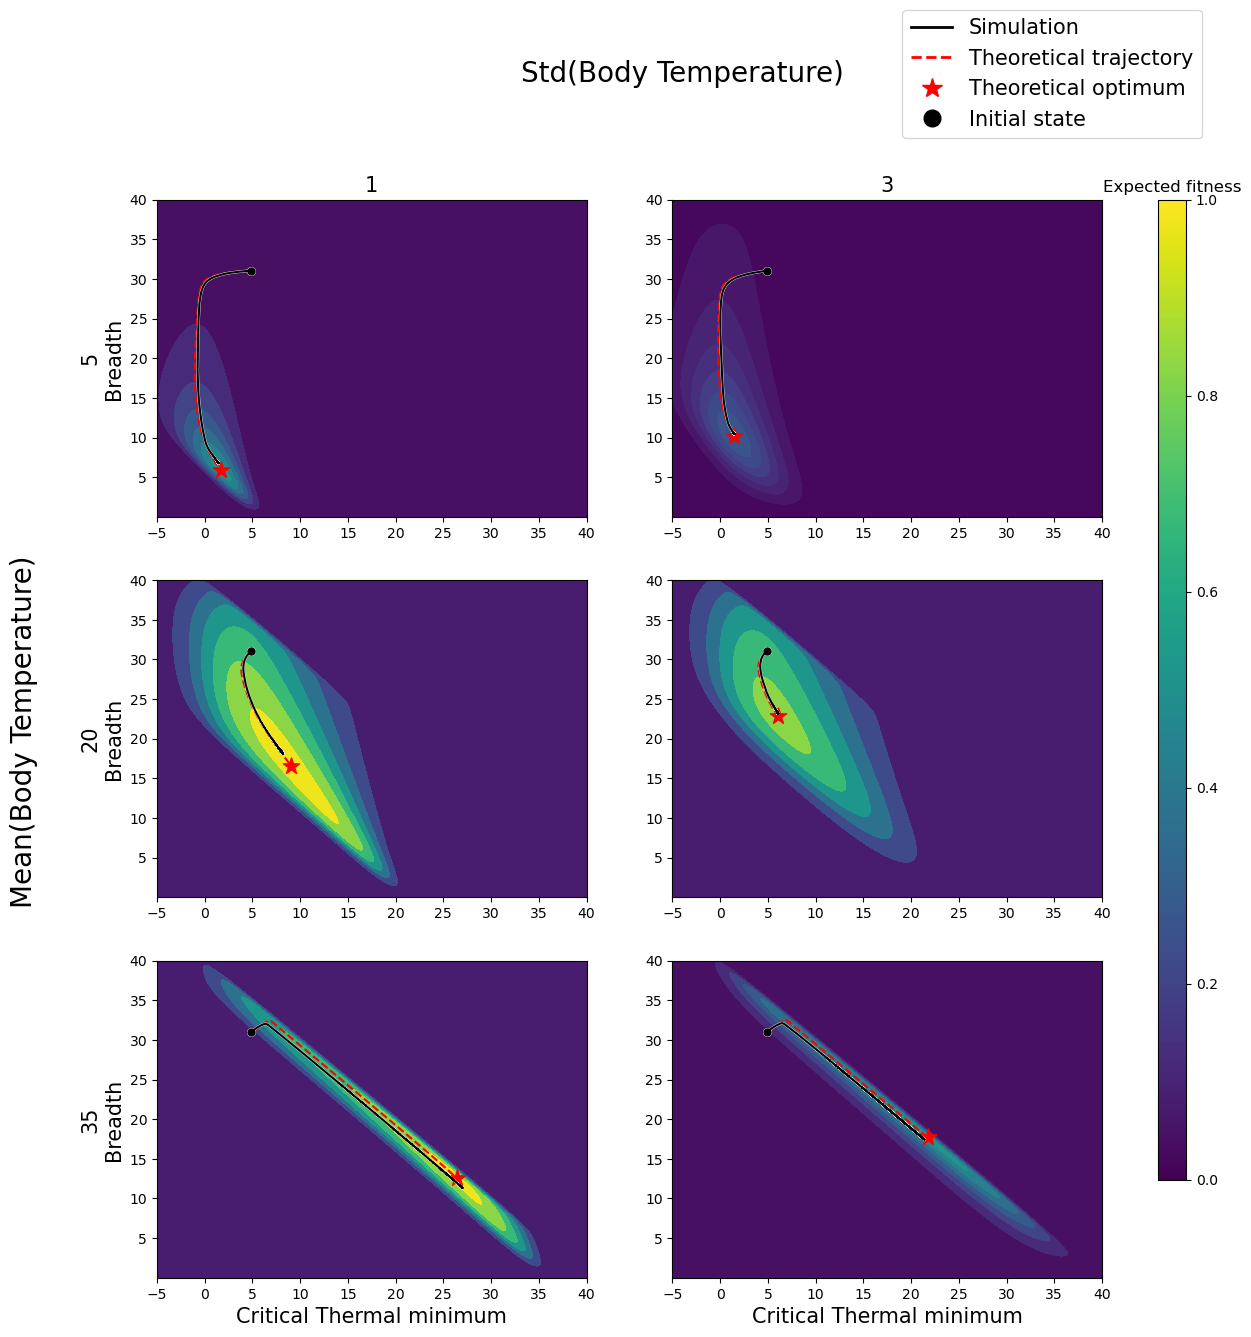

In [ ]:
# Figure S3
params_unique = pd.read_csv("../scripts/01_prepare_input_parameters/gaussian_params_unique.csv")
params_unique = params_unique[params_unique.STDEV_TEMP < 10]
# index for burn-in timing
t_0=500
muTs = params_unique.MEAN_TEMP.unique()
sigmaTs = params_unique.STDEV_TEMP.unique()

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize=(14, 14))       
# Store min and max cycle values for colorbar
all_cycle_values = []
contour_plot = None  # Store one contour plot for the colorbar
fig.supylabel("Mean(Body Temperature)", fontsize=20)
fig.suptitle("Std(Body Temperature)", fontsize=20)
for index, row in params_unique.iterrows():
    i = list(muTs).index(row.MEAN_TEMP)
    j = list(sigmaTs).index(row.STDEV_TEMP)
    muT = row.MEAN_TEMP
    sigmaT = row.STDEV_TEMP
    if sigmaT < 3:
        ax[i,j].set_ylabel(f"{muT}\nBreadth", fontsize=15)
    if muT > 34:
        ax[i,j].set_xlabel("Critical Thermal minimum", fontsize=15)
    elif muT < 10:
        ax[i,j].set_title(f"{sigmaT}", fontsize=15)
    print(f"muT={muT}, sigmaT={sigmaT}")
    outname = row.OUTNAME
    avg_df = np.load(f"{datadir}avg_df_{outname}.npy", allow_pickle=True).item()
    analytical_info = np.load(f"{datadir}{outname}_analytical_info.npz", allow_pickle=True)
    
    contour = ax[i,j].contourf(analytical_info['CTmin_grid'], 
                                  analytical_info['B_grid'], 
                                  analytical_info['W_contour'], 
                                  vmin=0, vmax=1, 
                                  cmap='viridis')
    
    
    ax[i,j].plot(analytical_info['sol'].item().y[0], analytical_info['sol'].item().y[1], linestyle='--', color='r')
    ax[i,j].plot(avg_df['CTmin_mean'], avg_df['B_mean'], color = 'w', linewidth=2, markevery=[0], markersize=5.5, marker='o')
    ax[i,j].plot(avg_df['CTmin_mean'], avg_df['B_mean'], color = 'k', markevery=[0], markersize=5, marker='o')
    ax[i,j].scatter(analytical_info['CTmin_opt'], analytical_info['B_opt'], color='r', marker='*', s=150)

# Adjust layout to make room for colorbars
fig.subplots_adjust(right=0.8)

cbar_ax = fig.add_axes([0.84, 0.18, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cm.ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap='viridis'),
             cax=cbar_ax, orientation='vertical')
cbar_ax.set_title("Expected fitness")

# Create custom legend handles
legend_handles = [
    Line2D([0], [0], color='k', linewidth=2, label='Simulation'),
    
    # Red dashed line for theoretical trajectory
    Line2D([0], [0], color='r', linestyle='--', linewidth=2, 
           label='Theoretical trajectory'),
    
    # Red star for theoretical optimum
    Line2D([0], [0], marker='*', color='w', markerfacecolor='r', 
           markeredgecolor='r', markersize=15, linestyle='None',
           label='Theoretical optimum'),
    # Black circle for initial state
    Line2D([0], [0], marker='o', color='k', markerfacecolor='k', 
        markeredgecolor='k', markersize=12, linestyle='None', 
        label='Initial state')
]

# Add the legend to the figure (outside the subplots)
fig.legend(handles=legend_handles, 
          loc='center left',  # or 'upper left', 'lower left', etc.
          bbox_to_anchor=(0.65, 0.97),  # Adjust position (x, y)
          fontsize=15)

fig.savefig("../figures/results-si-avg-trajectories.pdf", bbox_inches='tight')

muT=5, sigmaT=1
muT=5, sigmaT=3
muT=20, sigmaT=1
muT=20, sigmaT=3
muT=35, sigmaT=1
muT=35, sigmaT=3


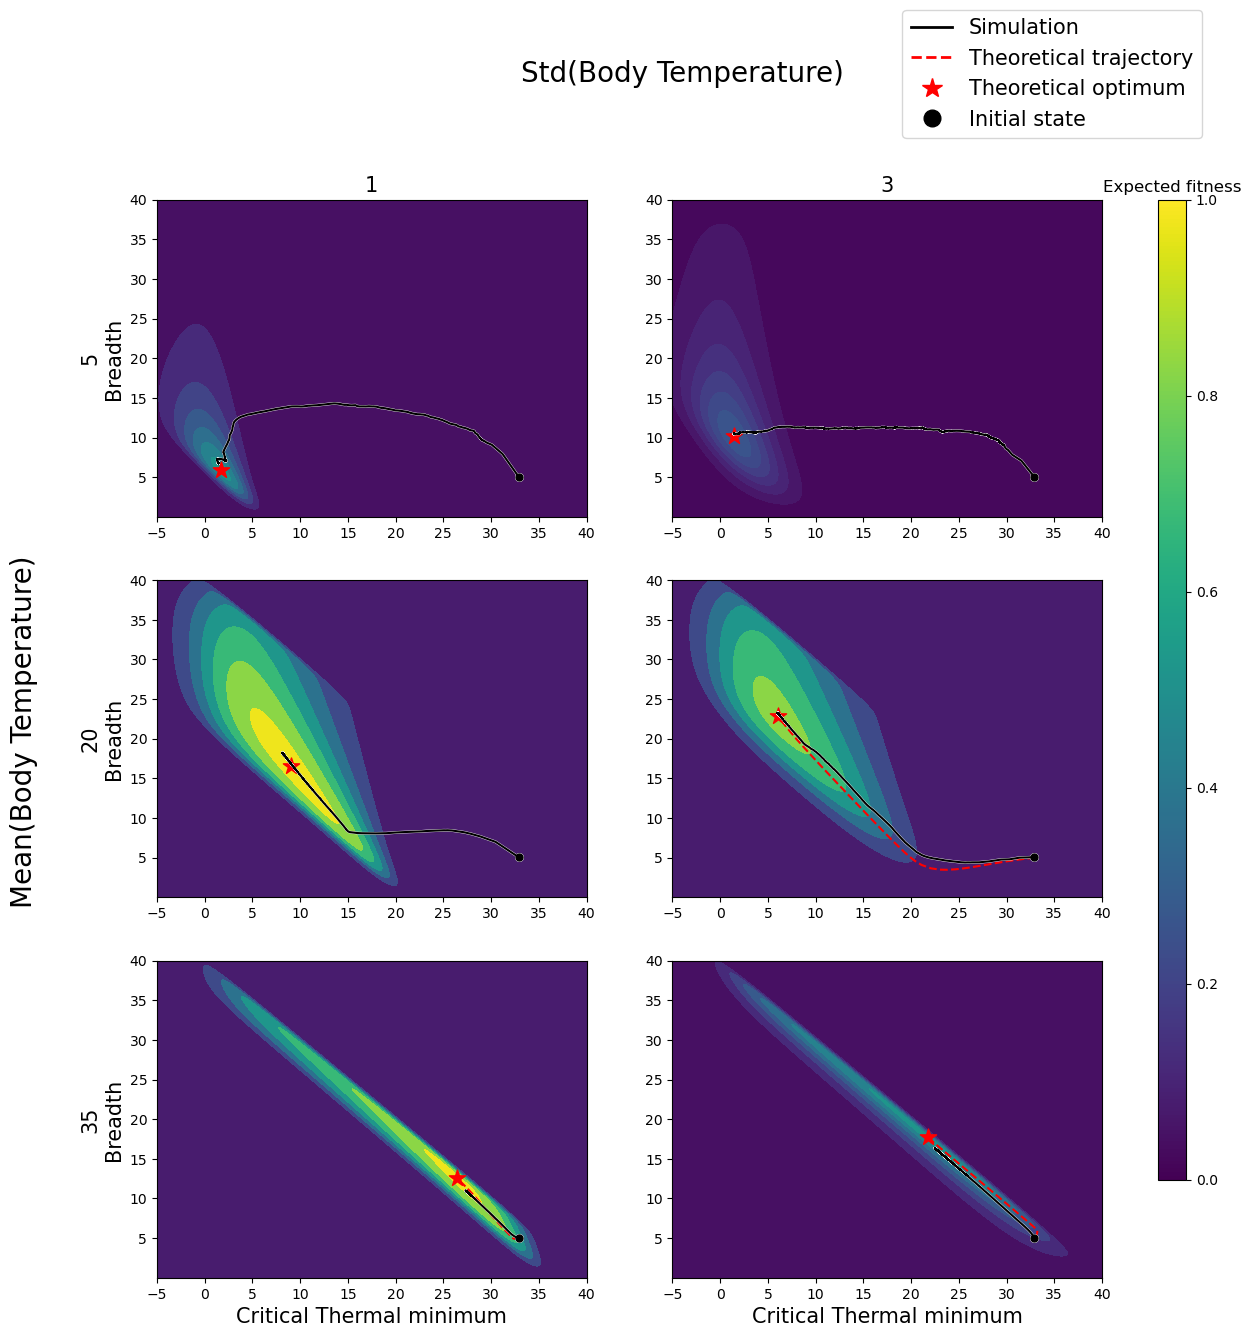

In [ ]:
# Figure S4
params_unique = pd.read_csv("../scripts/01_prepare_input_parameters/gaussian_alt_initial_params_unique.csv")
params_unique = params_unique[params_unique.STDEV_TEMP<10]
# index for burn-in timing
t_0=500
muTs = params_unique.MEAN_TEMP.unique()
sigmaTs = params_unique.STDEV_TEMP.unique()

fig, ax = plt.subplots(nrows = 3, ncols = 2, figsize=(14, 14))       
# Store min and max cycle values for colorbar
all_cycle_values = []

contour_plot = None  # Store one contour plot for the colorbar
fig.supylabel("Mean(Body Temperature)", fontsize=20)
fig.suptitle("Std(Body Temperature)", fontsize=20)
for index, row in params_unique.iterrows():
    i = list(muTs).index(row.MEAN_TEMP)
    j = list(sigmaTs).index(row.STDEV_TEMP)
    muT = row.MEAN_TEMP
    sigmaT = row.STDEV_TEMP

    if sigmaT < 3:
        ax[i,j].set_ylabel(f"{muT}\nBreadth", fontsize=15)
    if muT > 34:
        ax[i,j].set_xlabel("Critical Thermal minimum", fontsize=15)
    elif muT < 10:
        ax[i,j].set_title(f"{sigmaT}", fontsize=15)
    print(f"muT={muT}, sigmaT={sigmaT}")
    outname = row.OUTNAME
    avg_df = np.load(f"{datadir}avg_df_{outname}.npy", allow_pickle=True).item()
    analytical_info = np.load(f"{datadir}{outname}_analytical_info.npz", allow_pickle=True)
    contour = ax[i,j].contourf(analytical_info['CTmin_grid'], 
                                  analytical_info['B_grid'], 
                                  analytical_info['W_contour'], 
                                  vmin=0, vmax=1, 
                                  cmap='viridis')
    
    
    ax[i,j].plot(analytical_info['sol'].item().y[0], analytical_info['sol'].item().y[1], linestyle='--', color='r')
    ax[i,j].plot(avg_df['CTmin_mean'], avg_df['B_mean'], color = 'w', linewidth=2, markevery=[0], markersize=5.5, marker='o')
    ax[i,j].plot(avg_df['CTmin_mean'], avg_df['B_mean'], color = 'k', markevery=[0], markersize=5, marker='o')
    ax[i,j].scatter(analytical_info['CTmin_opt'], analytical_info['B_opt'], color='r', marker='*', s=150)

# Adjust layout to make room for colorbars
fig.subplots_adjust(right=0.8)

cbar_ax = fig.add_axes([0.84, 0.18, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cm.ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap='viridis'),
             cax=cbar_ax, orientation='vertical')
cbar_ax.set_title("Expected fitness")

# Create custom legend handles
legend_handles = [
    Line2D([0], [0], color='k', linewidth=2, label='Simulation'),
    
    # Red dashed line for theoretical trajectory
    Line2D([0], [0], color='r', linestyle='--', linewidth=2, 
           label='Theoretical trajectory'),
    
    # Red star for theoretical optimum
    Line2D([0], [0], marker='*', color='w', markerfacecolor='r', 
           markeredgecolor='r', markersize=15, linestyle='None',
           label='Theoretical optimum'),
    # Black circle for initial state
    Line2D([0], [0], marker='o', color='k', markerfacecolor='k', 
        markeredgecolor='k', markersize=12, linestyle='None', 
        label='Initial state')
]

# Add the legend to the figure (outside the subplots)
fig.legend(handles=legend_handles, 
          loc='center left',  # or 'upper left', 'lower left', etc.
          bbox_to_anchor=(0.65, 0.97),  # Adjust position (x, y)
          fontsize=15)

fig.savefig("../figures/results-si-avg-trajectories-alt-initial.pdf", bbox_inches='tight')

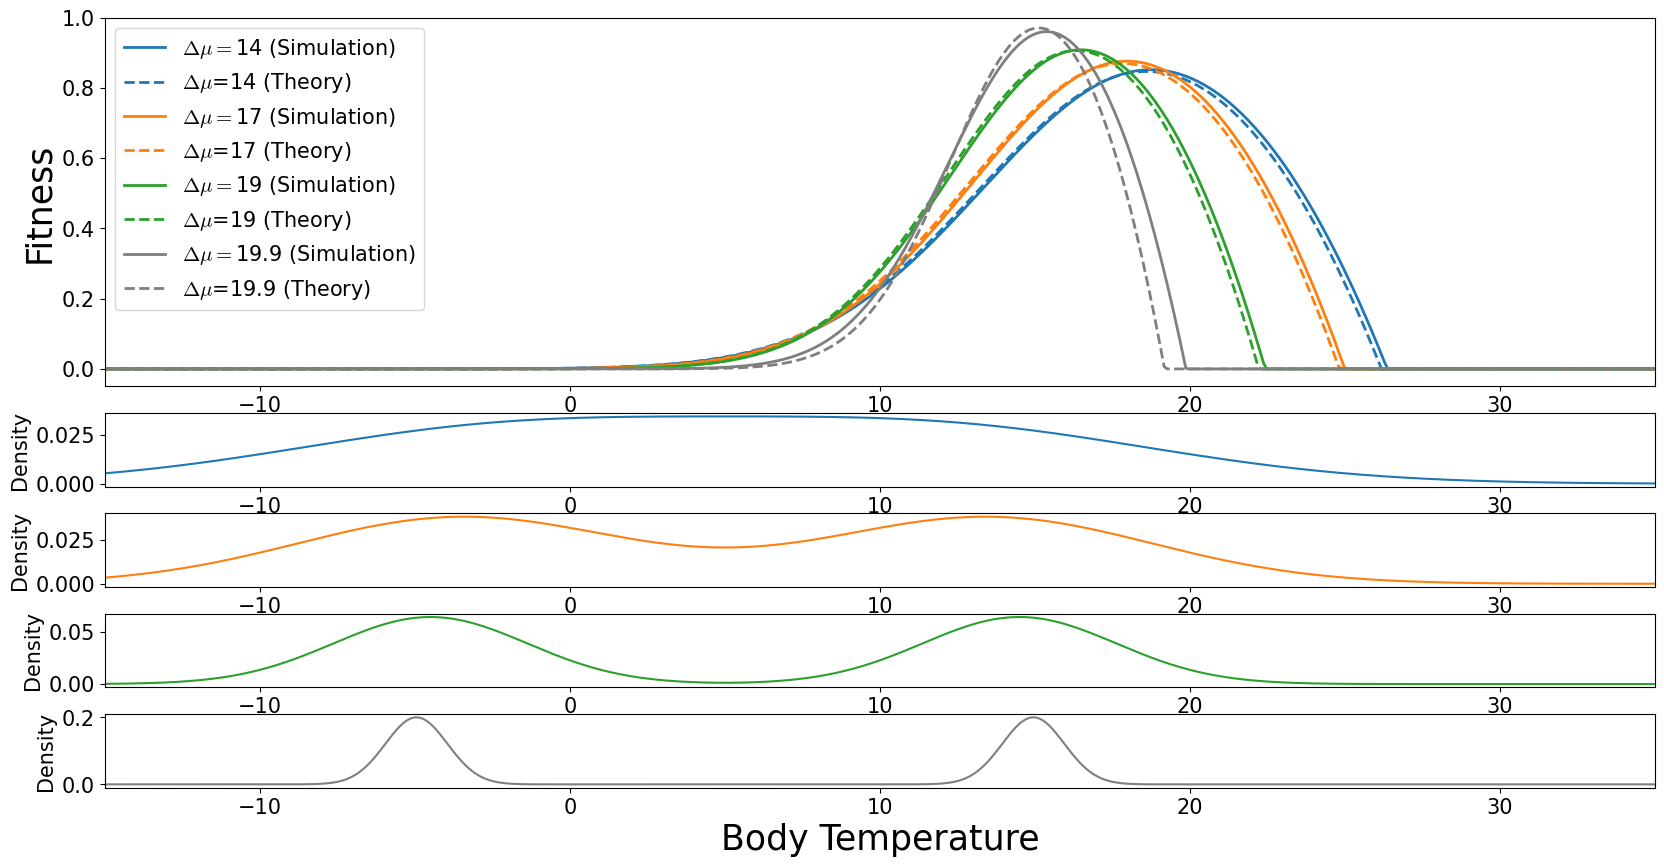

In [ ]:
# Figure S5
# modified w_TPC equations for bimodal distributions

from scipy.stats import norm as norm
def expected_w_TPC_no_recovery_bimodal(muT, deltamuT, sigmaT, CTmin, B):
    nr = tpc_object.num_days_per_gen 

    CTmin_array = np.array(CTmin, ndmin=1)
    B_array = np.array(B, ndmin=1)
    

    CTmin_grid, B_grid = np.meshgrid(CTmin_array, B_array)
    output = np.zeros(CTmin_grid.shape)
    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            CTmin = CTmin_grid[i,j]
            B = B_grid[i,j]
            CTmax = CTmin + B
            fun = lambda T: tpc_object.w_TPC(T=T, CTmin=CTmin, B=B) \
                * (0.5 * norm.pdf(T, muT-deltamuT/2, np.sqrt(sigmaT**2-deltamuT**2/4)) \
                    + 0.5 * norm.pdf(T, muT+deltamuT/2, np.sqrt(sigmaT**2-deltamuT**2/4)))
            if (sigmaT - deltamuT/2) < np.finfo(np.float64).tiny:
                integral = 0.5 * (tpc_object.w_TPC(T=muT-deltamuT/2, CTmin=CTmin, B=B) + 
                            tpc_object.w_TPC(T=muT+deltamuT/2, CTmin=CTmin, B=B))
            else:
                integral, err = scipy.integrate.quad(fun, CTmin, CTmax)
            r = 0.5 * norm.cdf(CTmax, muT-deltamuT/2, np.sqrt(sigmaT**2-deltamuT**2/4))\
                + 0.5 * norm.cdf(CTmax, muT+deltamuT/2, np.sqrt(sigmaT**2-deltamuT**2/4))
            if (1 - r) < np.finfo(np.float64).tiny:
                C = 1
            else:
                C = (1 - nr * r ** (nr - 1) + (-1 + nr) * r ** nr) / (nr * (1 - r)) + r ** (nr - 1)
            output[i,j] = C * integral
    return output


def optimize_expected_w_TPC_no_recovery_bimodal(muT, deltamuT, sigmaT, CTmin0, B0):
    '''
    Find optimal CTmin and B that maximize expected w_TPC using no-recovery model.
    CTmin0 and B0 are initial guess
    '''
    B_tiny = 1e-3
    def objective(params):
        CTmin, B = params
        expected_w_TPC = expected_w_TPC_no_recovery_bimodal(muT=muT, deltamuT=deltamuT, sigmaT=sigmaT, B=B, CTmin=CTmin)
        return -expected_w_TPC
    bnds = ((None, None), (B_tiny, None))
    results = scipy.optimize.minimize(objective, [CTmin0, B0], method='L-BFGS-B', bounds=bnds)
    return results.x


params = pd.read_csv("../scripts/01_prepare_input_parameters/two_normal_params.csv")
deltamuTs = params.SEP_MEAN_TEMP.unique()

plt.rcParams.update({'font.size': 15})
fig, ax = plt.subplots(figsize=(20,10), nrows=5, ncols=1, height_ratios=[5, 1, 1, 1, 1])
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:gray']
T_series = np.linspace(-15, 35, 500)

threshold = 0.5 # threshold for coloring - when the parameter is within critical value

ax[0].set_xlim((min(T_series), max(T_series)))
ax[0].set_ylim((-0.05, 1))
ax[4].set_xlabel("Body Temperature", fontsize=25)
ax[0].set_ylabel("Fitness", fontsize=25)
for i in range(1, 5):
    ax[i].set_ylabel("Density")
    ax[i].set_xlim((min(T_series), max(T_series)))

meanBs = []
for i, row in params.iterrows():
    log = pd.read_csv(f"{datadir}two_normal_SEP_MEAN_TEMP_{row.SEP_MEAN_TEMP:g}.txt")
    sep = row.SEP_MEAN_TEMP
    # preventing division by zero error if delta mu = stdev
    if np.abs(sep - 20) < np.finfo(np.float64).tiny:
        sep = 19.999 
    scale=np.sqrt(row.STDEV_TEMP**2 - sep**2/4)
    ax[i+1].plot(T_series, (0.5 * scipy.stats.norm.pdf(T_series, loc=row.MEAN_TEMP-sep/2, 
        scale=np.sqrt(row.STDEV_TEMP**2 - sep**2/4)) + \
        0.5 * scipy.stats.norm.pdf(T_series, loc=row.MEAN_TEMP+sep/2, 
        scale=np.sqrt(row.STDEV_TEMP**2 - sep**2/4))), color = colors[i])
for i, row in params.iterrows():
    log = pd.read_csv(f"{datadir}two_normal_SEP_MEAN_TEMP_{row.SEP_MEAN_TEMP:g}.txt")
    meanB = np.array(log.B_mean)[-1]
    meanCTmin = np.array(log.CTmin_mean)[-1]
    ax[0].plot(T_series, tpc_object.w_TPC(CTmin=meanCTmin, B=meanB, T=T_series), 
                    linewidth=2, 
                    color=colors[i], label=f'$\\Delta\\mu=${row.SEP_MEAN_TEMP:g} (Simulation)')

    CTmin0 = -10
    B0 = 30
    CTmin_opt, B_opt = optimize_expected_w_TPC_no_recovery_bimodal(row.MEAN_TEMP, row.SEP_MEAN_TEMP, row.STDEV_TEMP, CTmin0, B0)
    ax[0].plot(T_series, tpc_object.w_TPC(CTmin=CTmin_opt, B=B_opt, T=T_series), 
            color=colors[i], linestyle='--', linewidth=2,
            label=f"$\\Delta\\mu$={row.SEP_MEAN_TEMP:g} (Theory)")
ax[0].legend()
fig.savefig(f"../figures/bimodality_ver2.png", bbox_inches='tight')

ax[0].legend()

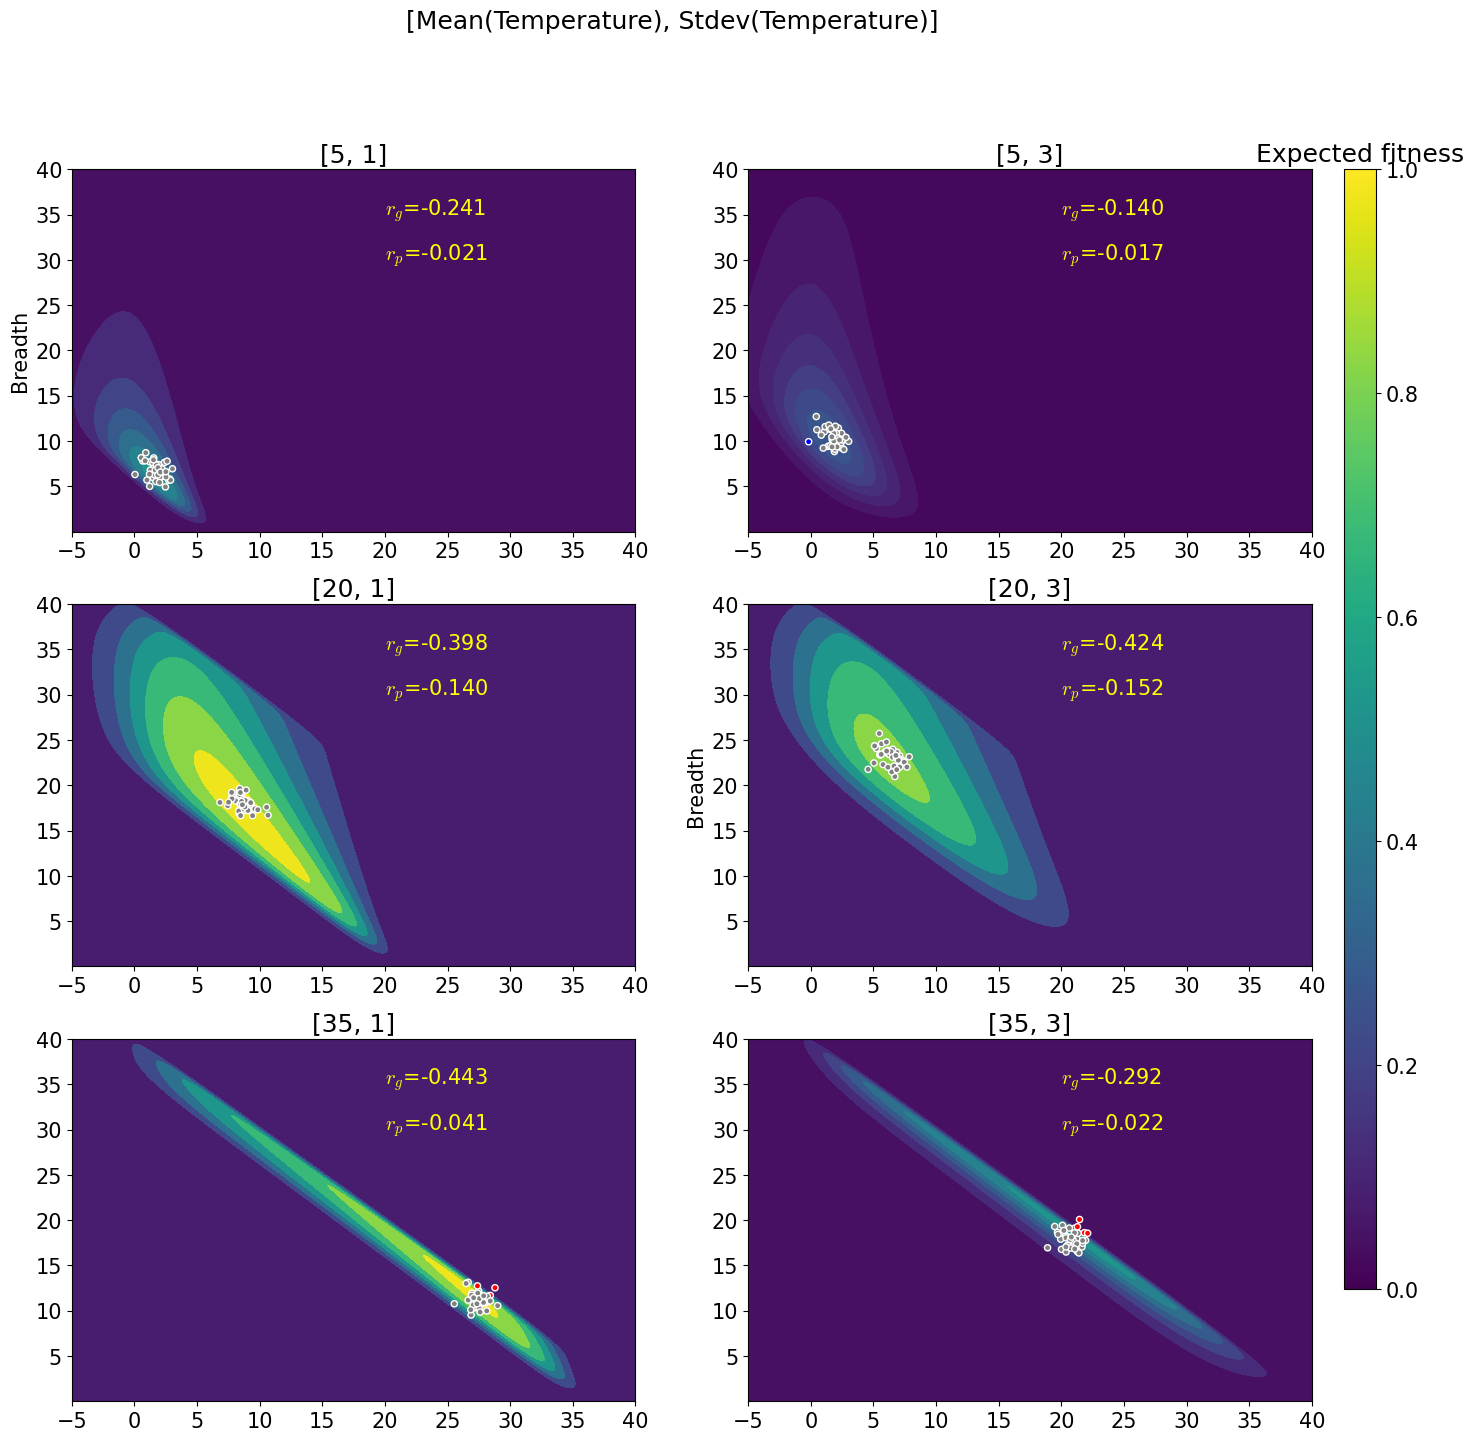

In [ ]:
# Figure S6
plt.rcParams.update({'font.size': 15})
params = pd.read_csv("../scripts/01_prepare_input_parameters/gaussian_params.csv")
params = params[(params.STDEV_TEMP < 10)]
params_sub = params[(params.seed == 29)]
params_sub = params_sub.sort_values(by=['MEAN_TEMP', 'STDEV_TEMP']).reset_index(drop=True)

muTs = params_sub.MEAN_TEMP.unique()
sigmaTs = params_sub.STDEV_TEMP.unique()
fig, ax = plt.subplots(figsize=(16, 16), nrows=3, ncols=2)
fig.suptitle("[Mean(Temperature), Stdev(Temperature)]")
threshold = 0.5 # threshold for coloring - when the parameter is within critical value

for i, subax in enumerate(ax.flat):
    if i%3==0:
        subax.set_ylabel("Breadth")
    if i>=6:
        subax.set_xlabel("Critical Thermal minimum")
    
for index, row in params_sub.iterrows():
    # locate muT and sigmaT in the unique list
    i = list(muTs).index(row.MEAN_TEMP)
    j = list(sigmaTs).index(row.STDEV_TEMP)
    B_and_CTmin = pd.read_csv(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_seed_{row.seed}.csv", engine='python', sep=', ')
    analytical_info = np.load(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_analytical_info.npz", allow_pickle=True)

    Bs_final = np.array(B_and_CTmin.B)
    CTmins_final = np.array(B_and_CTmin.CTmin)
    random.seed(4)
    sample_idx = random.sample(range(len(Bs_final)), 40)
    colors = []
    for B, CTmin in zip(Bs_final[sample_idx], CTmins_final[sample_idx]):
        w_CTmin = tpc_object.w_CTmin(CTmin)
        w_B = tpc_object.w_B(B)
        CTmax = CTmin + B
        w_CTmax = tpc_object.w_CTmax(CTmax)
        if (w_B < threshold) and (w_CTmin > threshold) and (w_CTmax > threshold):
            # Too generalist
            color = 'g'
            alpha = 1
        elif (w_CTmin < threshold) and (w_B > threshold) and (w_CTmax > threshold):
            # Too much cold adaptation
            color = 'b'
            alpha = 1
        elif (w_B > threshold) and (w_CTmin > threshold) and (w_CTmax < threshold):
            # Too much heat adaptation
            color = 'r'
            alpha = 1
        elif (np.array([w_B, w_CTmin, w_CTmax]) > threshold).all():
            # not limited by any of 3 physiological constraints
            color = 'grey'
            alpha = 1
        else:
            print("constrained by more than one types of limits")
            continue
        colors.append(color)


    contour = ax[i,j].contourf(analytical_info['CTmin_grid'], 
                                  analytical_info['B_grid'], 
                                  analytical_info['W_contour'], 
                                  vmin=0, vmax=1, 
                                  cmap='viridis')
    ax[i,j].scatter(CTmins_final[sample_idx], Bs_final[sample_idx], marker='o', edgecolor='w', facecolor=colors, s=20)
    ax[i,j].set_title(f"[{row.MEAN_TEMP}, {row.STDEV_TEMP}]")
    
    # Calculate genetic covariance (sum of effect sizes in QTN_CTmin vs. QTN_B)
    ts = tskit.load(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_seed_{row.seed}.trees")
    G_CTmin_list = np.zeros(ts.num_individuals)
    G_B_list = np.zeros(ts.num_individuals)
    
    var_idx = 0
    for var in ts.variants():
        gene_dose = var.genotypes[::2] + var.genotypes[1::2]
        s = var.site.mutations[0].metadata['mutation_list'][0]['selection_coeff']
        if var.site.mutations[0].metadata['mutation_list'][0]['mutation_type'] == 2:
        # m2, i.e. QTN for B
            G_B_list += gene_dose * s
        elif var.site.mutations[0].metadata['mutation_list'][0]['mutation_type'] == 3:
            G_CTmin_list += gene_dose * s
        else:
            print("undefined mutation type")
        var_idx += 1

    g_corr = np.corrcoef(G_B_list, G_CTmin_list)[0,1]
    ax[i,j].text(20, 35, f"$r_g$={g_corr:.3f}", color='yellow')
    p_corr = np.corrcoef(Bs_final, CTmins_final)[0,1]
    ax[i,j].text(20, 30, f"$r_p$={p_corr:.3f}", color='yellow')
cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cm.ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap='viridis'),
             cax=cbar_ax, orientation='vertical')
cbar_ax.set_title("Expected fitness")
fig.savefig("../figures/SI_Fig2_sample_TPCs_on_fitness_landscape.pdf", bbox_inches='tight')

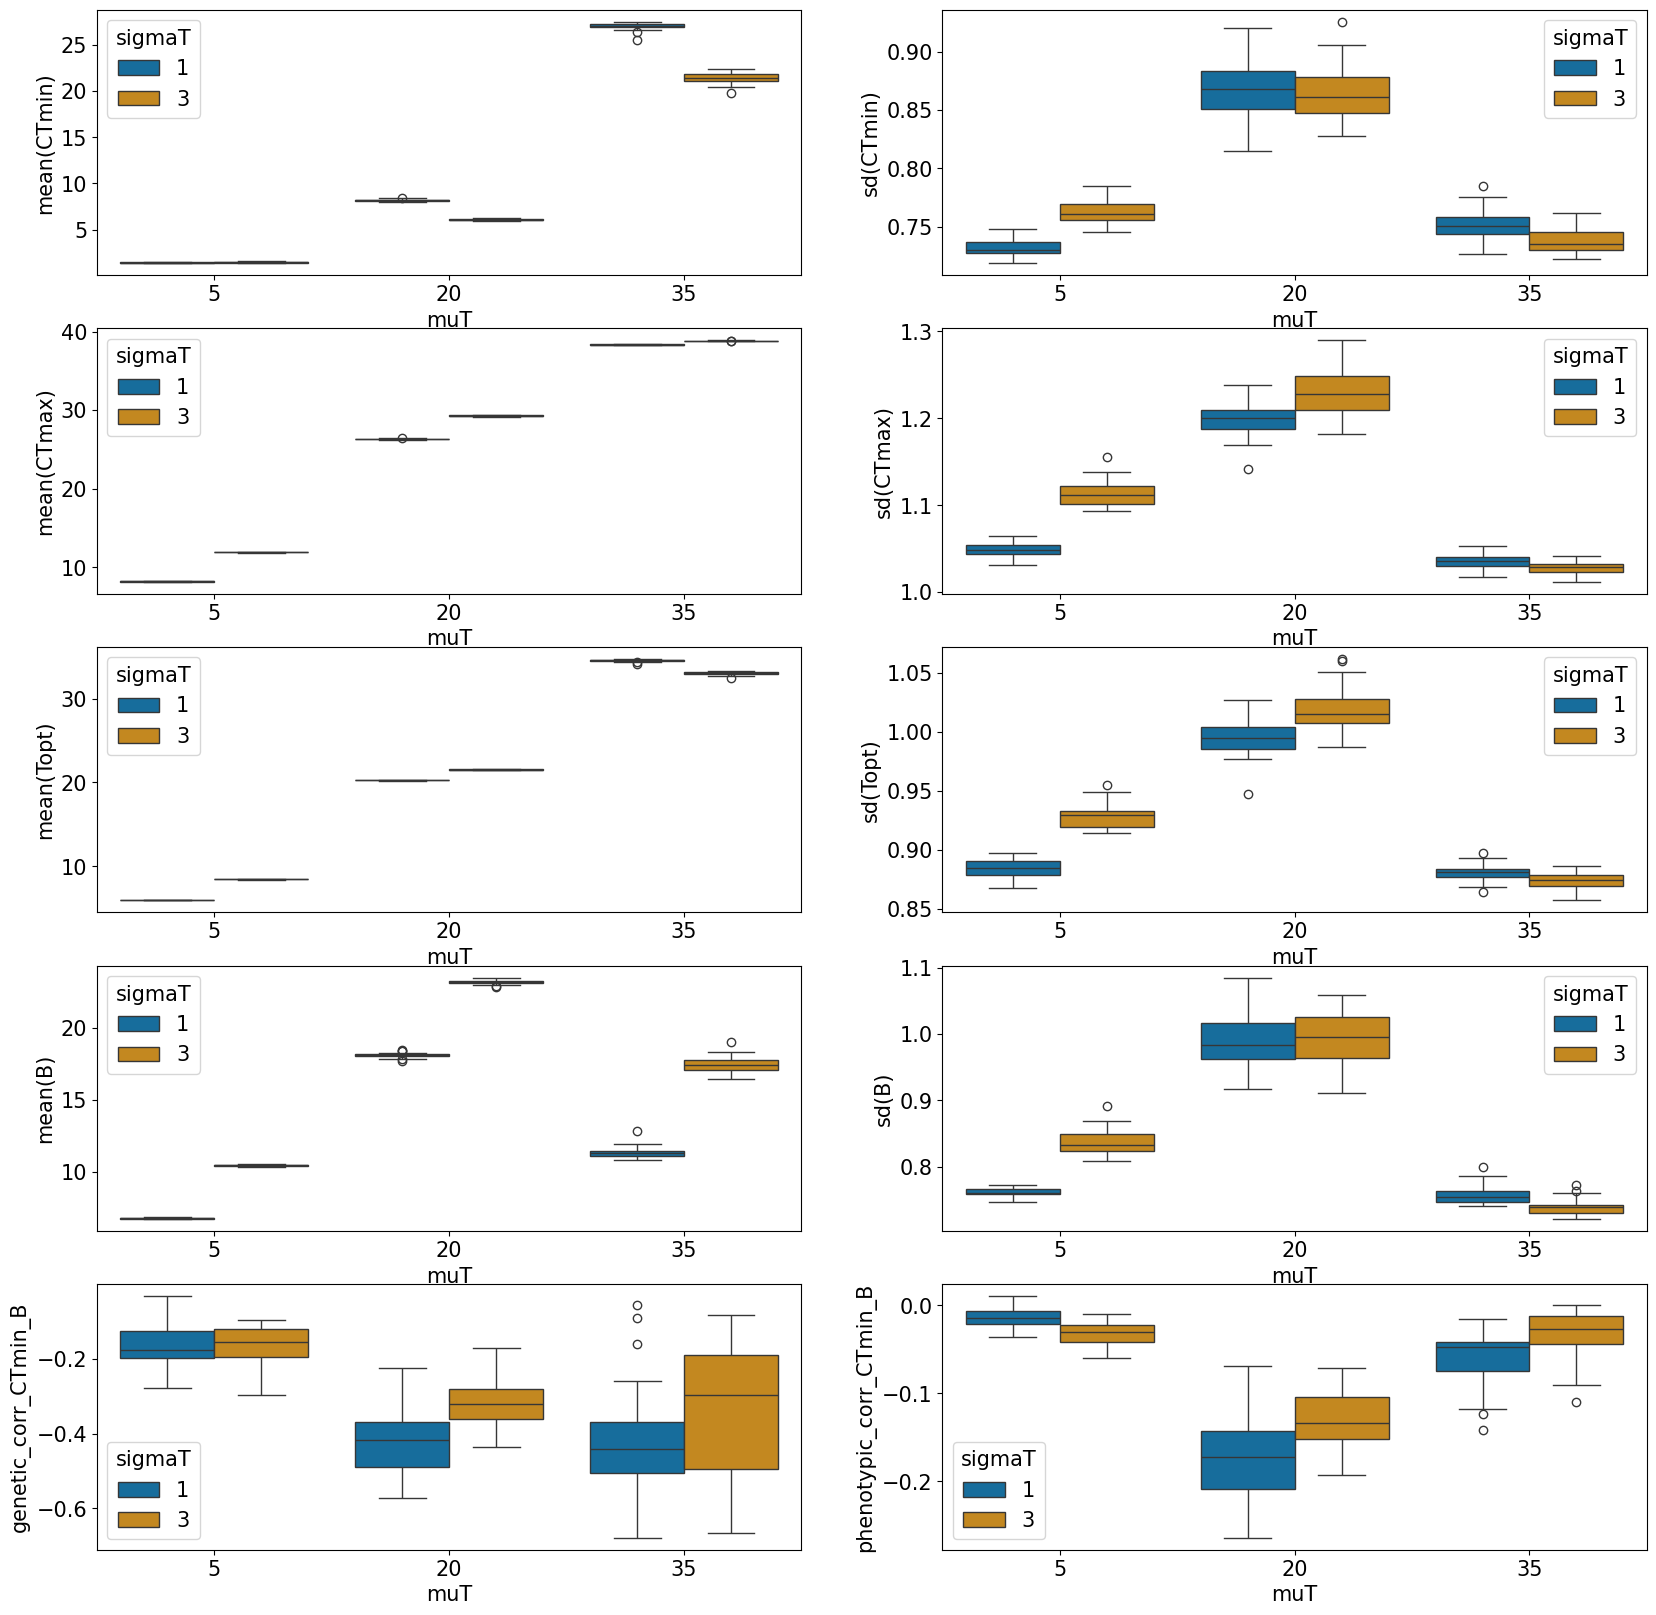

In [ ]:
# Figure S7
import seaborn as sns
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(20,20))

# Create dataframe for the boxplots.

df = {'muT':[], 'sigmaT':[], 
                   'mean(CTmin)':[], 'sd(CTmin)':[], 
                   'mean(CTmax)':[], 'sd(CTmax)':[], 
                   'mean(Topt)':[], 'sd(Topt)':[], 
                   'mean(B)':[], 'sd(B)':[], 
                   'genetic_corr_CTmin_B':[], 'phenotypic_corr_CTmin_B': []}

def tpc_param_stats(row):
    B_and_CTmin = pd.read_csv(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_seed_{row.seed}.csv", engine='python', sep=', ')
    Bs = B_and_CTmin.B
    CTmins = B_and_CTmin.CTmin
    CTmaxs = Bs + CTmins
    Topts = CTmins + 2/3 * Bs
    df['muT'].append(row.MEAN_TEMP)
    df['sigmaT'].append(row.STDEV_TEMP)
    df['mean(CTmin)'].append(np.mean(CTmins))
    df['sd(CTmin)'].append(np.std(CTmins))
    df['mean(CTmax)'].append(np.mean(CTmaxs))
    df['sd(CTmax)'].append(np.std(CTmaxs))
    df['mean(Topt)'].append(np.mean(Topts))
    df['sd(Topt)'].append(np.std(Topts))
    df['mean(B)'].append(np.mean(Bs))
    df['sd(B)'].append(np.std(Bs))
    df['phenotypic_corr_CTmin_B'].append(np.corrcoef(Bs, CTmins)[0,1])
        # Calculate genetic covariance (sum of effect sizes in QTN_CTmin vs. QTN_B)
    ts = tskit.load(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_seed_{row.seed}.trees")
    G_CTmin_list = np.zeros(ts.num_individuals)
    G_B_list = np.zeros(ts.num_individuals)
    
    var_idx = 0
    for var in ts.variants():
        gene_dose = var.genotypes[::2] + var.genotypes[1::2]
        s = var.site.mutations[0].metadata['mutation_list'][0]['selection_coeff']
        if var.site.mutations[0].metadata['mutation_list'][0]['mutation_type'] == 2:
        # m2, i.e. QTN for B
            G_B_list += gene_dose * s
        elif var.site.mutations[0].metadata['mutation_list'][0]['mutation_type'] == 3:
            G_CTmin_list += gene_dose * s
        else:
            print("undefined mutation type")
        var_idx += 1

    df['genetic_corr_CTmin_B'].append(np.corrcoef(G_B_list, G_CTmin_list)[0,1])
params = pd.read_csv("../scripts/01_prepare_input_parameters/gaussian_params.csv")
params = params[(params.STDEV_TEMP < 10)]
params.apply(tpc_param_stats, axis=1)
df = pd.DataFrame(df)

for i, key in enumerate(df.keys()[2:]):
    sns.boxplot(ax=ax.flat[i],
                x="muT",
                y=f"{key}",
                hue="sigmaT",
                palette=sns.color_palette('colorblind', 2), 
                data=df)
    ax.flat[i].set_ylabel(f"{key}", fontsize=15)

fig.savefig("../figures/result-s1-boxplots.pdf", bbox_inches='tight')

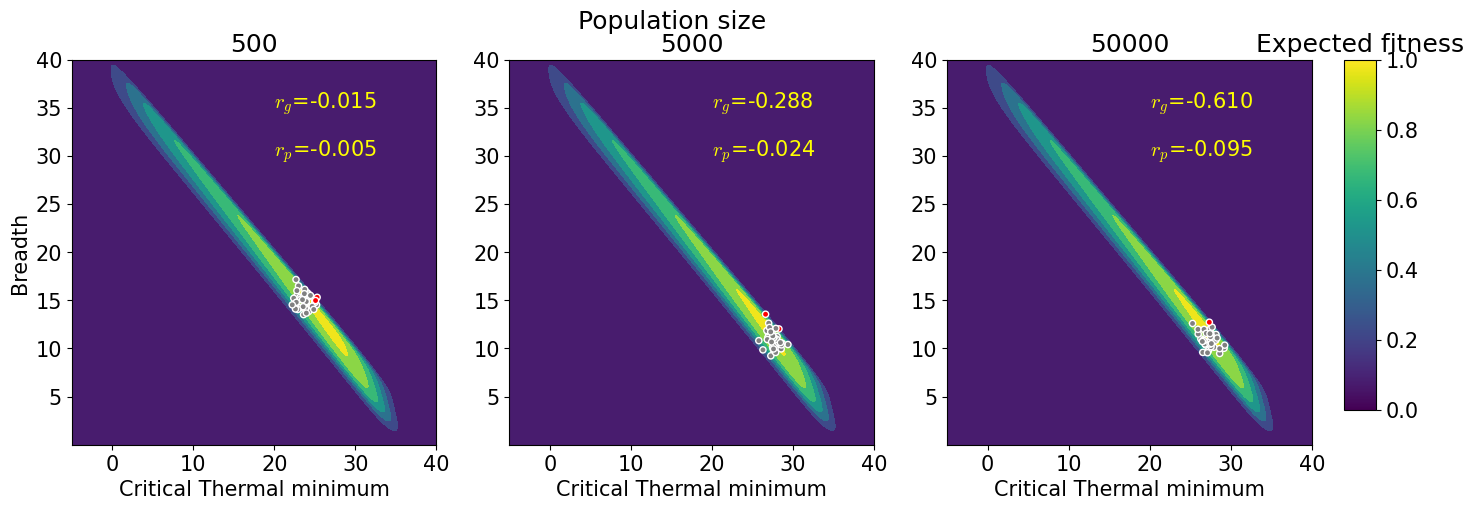

In [ ]:
# Figure S8
params = pd.read_csv("../scripts/01_prepare_input_parameters/temp_trop_params.csv")
params_sub = params[(params.seed ==29) & (params.STDEV_TEMP < 10)] #

Ns = params_sub.N_POP.unique()
fig, ax = plt.subplots(figsize=(16, 5), nrows=1, ncols=3)
fig.suptitle("Population size")
threshold = 0.5 # threshold for coloring - when the parameter is within critical value

ax[0].set_ylabel("Breadth")
for i in range(3):
    ax[i].set_xlabel("Critical Thermal minimum")
for index, row in params_sub.iterrows():
    # locate muT and sigmaT in the unique list
    i = list(sigmaTs).index(row.STDEV_TEMP)
    j = list(Ns).index(row.N_POP)
    B_and_CTmin = pd.read_csv(f"{datadir}MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_N_{row.N_POP}_seed_{row.seed}.csv", engine='python')
    analytical_info = np.load(f"{datadir}MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_N_{row.N_POP}_analytical_info.npz", allow_pickle=True)

    Bs_final = np.array(B_and_CTmin.B)
    CTmins_final = np.array(B_and_CTmin.CTmin)
    random.seed(4)
    sample_idx = random.sample(range(len(Bs_final)), 40)
    colors = []
    for B, CTmin in zip(Bs_final[sample_idx], CTmins_final[sample_idx]):
        w_CTmin = tpc_object.w_CTmin(CTmin)
        w_B = tpc_object.w_B(B)
        CTmax = CTmin + B
        w_CTmax = tpc_object.w_CTmax(CTmax)
        if (w_B < threshold) and (w_CTmin > threshold) and (w_CTmax > threshold):
            # Too generalist
            color = 'g'
            alpha = 1
        elif (w_CTmin < threshold) and (w_B > threshold) and (w_CTmax > threshold):
            # Too much cold adaptation
            color = 'b'
            alpha = 1
        elif (w_B > threshold) and (w_CTmin > threshold) and (w_CTmax < threshold):
            # Too much heat adaptation
            color = 'r'
            alpha = 1
        elif (np.array([w_B, w_CTmin, w_CTmax]) > threshold).all():
            # not limited by any of 3 physiological constraints
            color = 'grey'
            alpha = 1
        else:
            print("constrained by more than one types of limits")
            continue
        colors.append(color)


    contour = ax[j].contourf(analytical_info['CTmin_grid'], 
                                  analytical_info['B_grid'], 
                                  analytical_info['W_contour'], 
                                  vmin=0, vmax=1, 
                                  cmap='viridis')
    ax[j].scatter(CTmins_final[sample_idx], Bs_final[sample_idx], marker='o', edgecolor='w', facecolor=colors, s=20)
    ax[j].set_title(f"{row.N_POP}")
    
    # Calculate genetic covariance (sum of effect sizes in QTN_CTmin vs. QTN_B)
    ts = tskit.load(f"{datadir}MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_N_{row.N_POP}_seed_{row.seed}.trees")
    G_CTmin_list = np.zeros(ts.num_individuals)
    G_B_list = np.zeros(ts.num_individuals)
    
    var_idx = 0
    for var in ts.variants():
        gene_dose = var.genotypes[::2] + var.genotypes[1::2]
        s = var.site.mutations[0].metadata['mutation_list'][0]['selection_coeff']
        if var.site.mutations[0].metadata['mutation_list'][0]['mutation_type'] == 2:
        # m2, i.e. QTN for B
            G_B_list += gene_dose * s
        elif var.site.mutations[0].metadata['mutation_list'][0]['mutation_type'] == 3:
            G_CTmin_list += gene_dose * s
        else:
            print("undefined mutation type")
        var_idx += 1

    g_corr = np.corrcoef(G_B_list, G_CTmin_list)[0,1]
    ax[j].text(20, 35, f"$r_g$={g_corr:.3f}", color='yellow')
    p_corr = np.corrcoef(Bs_final, CTmins_final)[0,1]
    ax[j].text(20, 30, f"$r_p$={p_corr:.3f}", color='yellow')
cbar_ax = fig.add_axes([0.92, 0.18, 0.02, 0.7])  # [left, bottom, width, height]
fig.colorbar(cm.ScalarMappable(norm=Normalize(vmin=0, vmax=1), cmap='viridis'),
             cax=cbar_ax, orientation='vertical')
cbar_ax.set_title("Expected fitness")
fig.savefig("../figures/trop_samples.pdf", bbox_inches='tight')

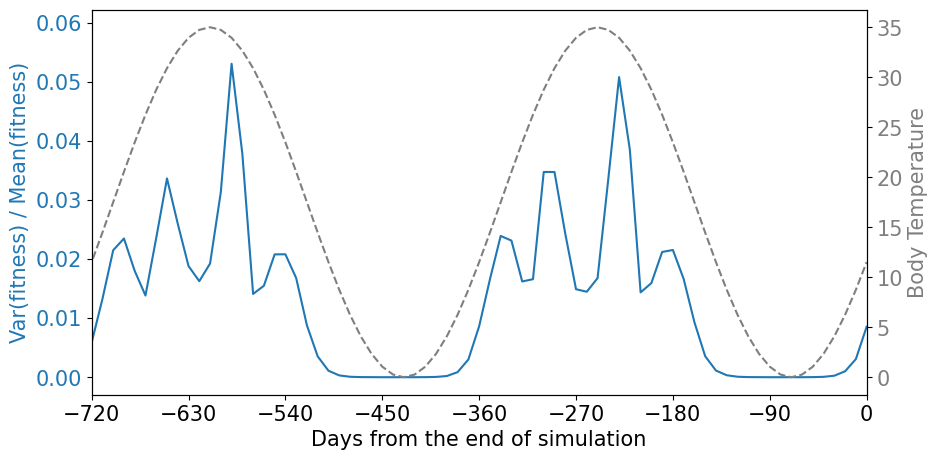

In [ ]:
# Figure S9
CTmin_critical = 0
B_critical = 20
log = pd.read_csv(f"{datadir}sine_test_CTmin_critical_{CTmin_critical}_B_critical_{B_critical}.txt")
# Use only the last 10 years of the data (1 yr = 360 days in this example)
log['day_from_end_of_sim'] = log.day - max(log.day)
log2 = log[log.day_from_end_of_sim > - 3601]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(log2.day_from_end_of_sim,log2.fitness_sd ** 2 / log2.fitness_mean, color='tab:blue')
ax2 = ax.twinx()
ax2.plot(log2.day_from_end_of_sim, log2.Temp, color='tab:grey', linestyle='--')
ax.set_xlim((-720, 0))
ax.tick_params(axis='y', labelcolor='tab:blue')

ax2.tick_params(axis='y', labelcolor='tab:grey')
ax.set_ylabel("Var(fitness) / Mean(fitness)", color='tab:blue')
ax2.set_ylabel("Body Temperature", color='tab:grey')
ax.set_xlabel("Days from the end of simulation")
ax.set_xticks(np.arange(-720, 1, 90))
fig.savefig("../figures/SI_fig_summer_winter_var_w.pdf")
#

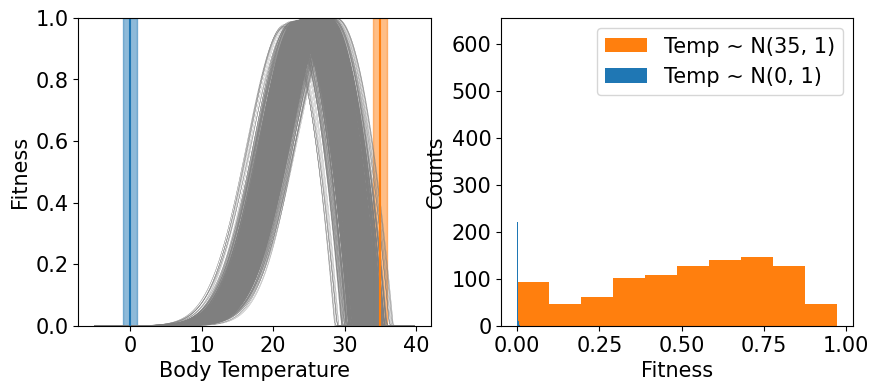

In [ ]:
# Figure S10
# Let's use the B and CTmin list
B_and_CTmin = pd.read_csv(f"{datadir}sine_test_CTmin_critical_{CTmin_critical}_B_critical_{B_critical}.csv", engine='python')
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
n_sample = 1000
sd_temp = 1
high_mean_temp = 30
low_mean_temp = 5
high_temp_fitness_list = []
low_temp_fitness_list = []
idxs = np.random.choice(range(len(B_and_CTmin)), size=n_sample)
for i in idxs:
    high_temp_fitness = tpc_object.w_TPC(T=np.random.random(size=1) * sd_temp + high_mean_temp, 
                     CTmin=B_and_CTmin.CTmin[i],
                     B=B_and_CTmin.B[i])
    high_temp_fitness_list.append(high_temp_fitness)
    low_temp_fitness = tpc_object.w_TPC(T=np.random.random(size=1) * sd_temp + low_mean_temp, 
                     CTmin=B_and_CTmin.CTmin[i],
                     B=B_and_CTmin.B[i])
    low_temp_fitness_list.append(low_temp_fitness)
ax[1].hist(high_temp_fitness_list, label='Temp ~ N(35, 1)', color='tab:orange')
ax[1].hist(low_temp_fitness_list, label='Temp ~ N(0, 1)', color='tab:blue')
ax[1].legend()
ax[1].set_ylabel("Counts")
ax[0].set_ylabel("Fitness")
T_list = np.arange(-5, 40, 0.2)
for i in idxs:
    curve = tpc_object.w_TPC(T=T_list, 
                     CTmin=B_and_CTmin.CTmin[i],
                     B=B_and_CTmin.B[i])
    ax[0].plot(T_list, curve, color='tab:grey', linewidth=0.2)
ax[0].vlines(x = 0, ymin=0, ymax=1, color='tab:blue')
ax[0].axvspan(xmin=-1, xmax=1, ymin=0, ymax=1, color='tab:blue', alpha=0.5)
ax[0].vlines(x = 35, ymin=0, ymax=1, color='tab:orange')
ax[0].axvspan(xmin=34, xmax=36, ymin=0, ymax=1, color='tab:orange', alpha=0.5)
ax[1].set_xlabel("Fitness")
ax[0].set_xlabel("Body Temperature")
ax[0].set_ylim((0,1))
fig.savefig("../figures/SI_asymmetric_TPC.pdf", bbox_inches='tight')

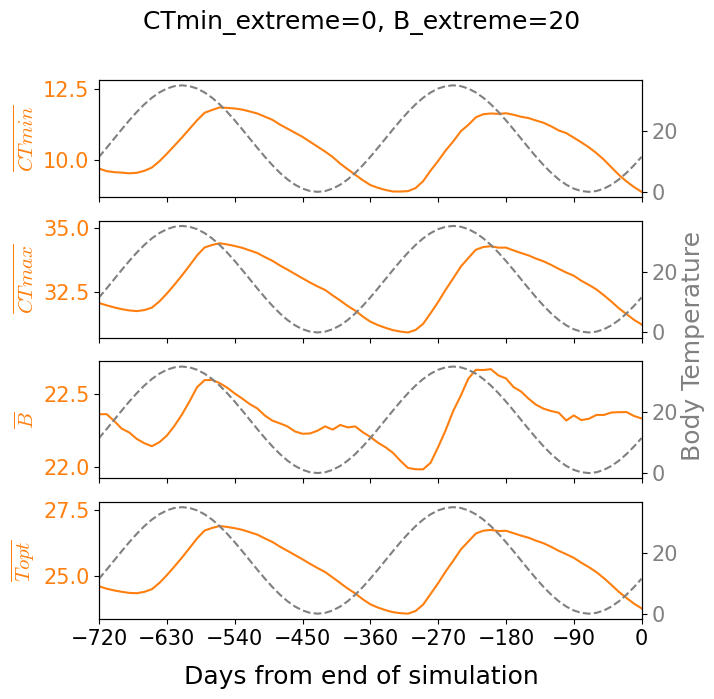

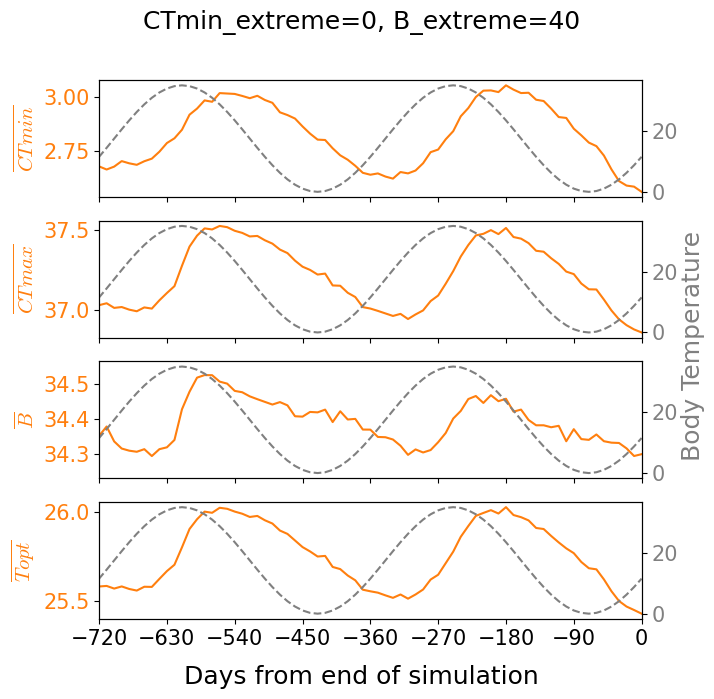

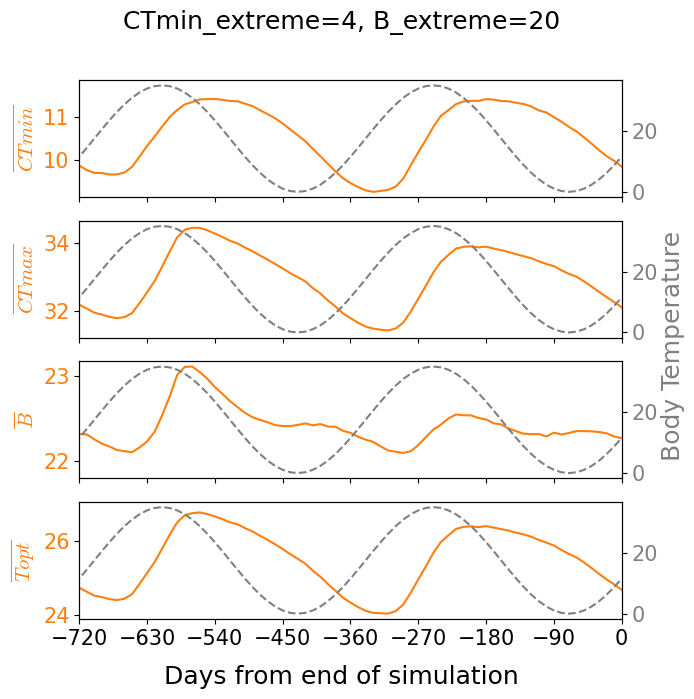

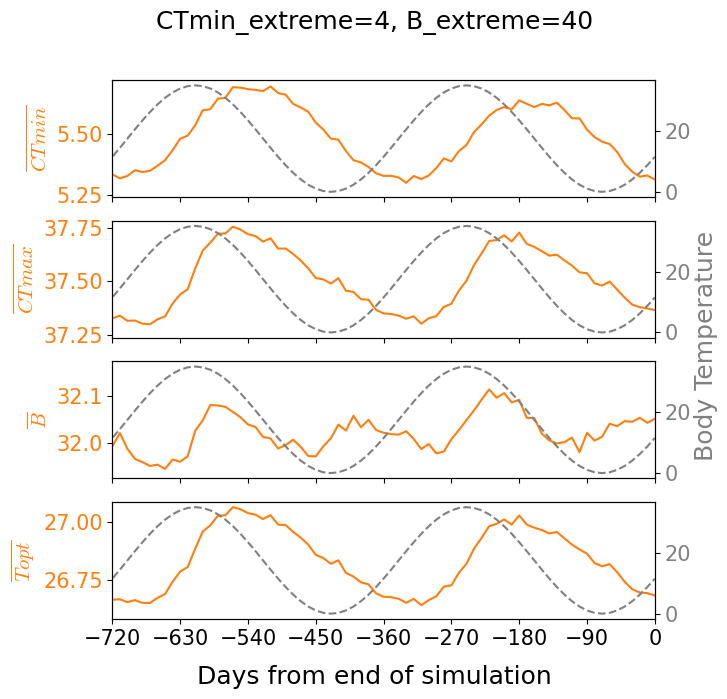

In [ ]:
# Figure S11
import itertools
CTmin_criticals = [0, 4]
B_criticals = [20, 40]
for CTmin_critical, B_critical in itertools.product(CTmin_criticals, B_criticals):
    log = pd.read_csv(f"{datadir}sine_test_CTmin_critical_{CTmin_critical}_B_critical_{B_critical}.txt")
    # Use only the last 10 years of the data (1 yr = 360 days in this example)
    log['day_from_end_of_sim'] = log.day - max(log.day)
    log2 = log[log.day_from_end_of_sim > - 3601]

    fig, ax = plt.subplots(4, 1, figsize=(7, 7), sharex=True)
    fig.suptitle(f"CTmin_extreme={CTmin_critical}, B_extreme={B_critical}")
    ylist = [log2.CTmin_mean, log2.CTmax_mean, log2.B_mean, log2.Topt_mean]
    ylabels = [ r"$\overline{CTmin}$", r"$\overline{CTmax}$", r"$\overline{B}$", r"$\overline{Topt}$"]
    fig.supxlabel("Days from end of simulation")
    fig.supylabel("Body Temperature", x=0.99, ha='right', va='center', color='grey')
    for i in range(4):
        ax[i].plot(log2.day_from_end_of_sim, ylist[i], color="tab:orange")
        ax[i].set_xlim((-720, 0))
        ax[i].set_xticks(np.arange(-720, 1, 90))
        ax[i].set_ylabel(ylabels[i], color="tab:orange")
        ax[i].tick_params(axis='y', labelcolor='tab:orange')
        ax2 = ax[i].twinx()
        ax2.plot(log2.day_from_end_of_sim, log2.Temp, color="grey", linestyle="--")
        ax2.tick_params(axis='y', labelcolor='grey')
    fig.savefig(f'../figures/sine_CTmin_extreme_{CTmin_critical}_B_extreme_{B_critical}.pdf', bbox_inches='tight')

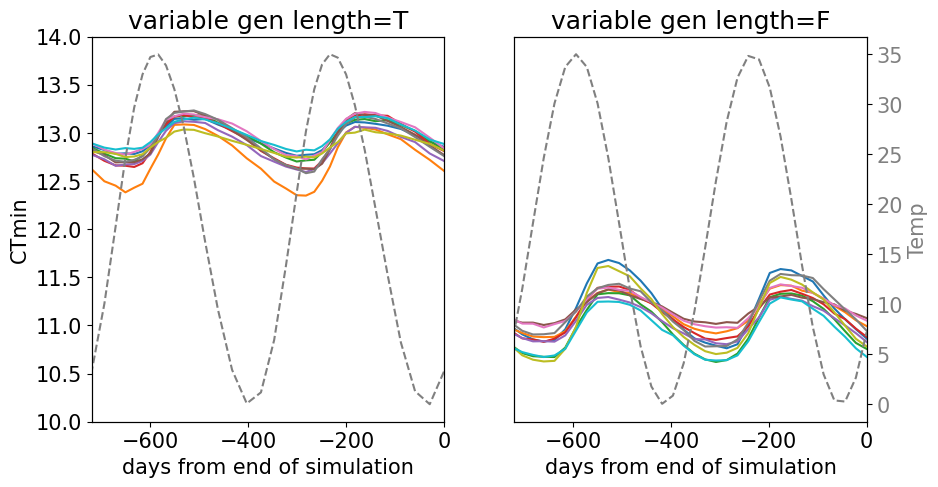

In [ ]:
# Figure S12

sine3_params = pd.read_csv("../scripts/01_prepare_input_parameters/sine3_params.csv")
kinds = ['T', 'F']
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

ax2 = [None, None]
def plot_sine3(row):
    if row.seed < 10:
        if os.path.isfile(f"{datadir}/{row.OUTNAME}.trees"):
            log = pd.read_csv(f"{datadir}/{row.OUTNAME}.txt")
            i = kinds.index(row.GEN_LEN_DEPENDS_ON_TEMP)
            ax.flat[i].plot(log.day - max(log.day), log.CTmin_mean)
        if row.seed == 0:
            ax2[i] = ax[i].twinx()
            ax2[i].plot(log.day - max(log.day), log.Temp, color="grey", linestyle="--")
            ax2[i].tick_params(axis='y', labelcolor='grey')
    
sine3_params.apply(plot_sine3, axis=1)

for i, kind in enumerate(['T', 'F']):
    ax.flat[i].set_xlim((-720, 0))
    ax.flat[i].set_ylim((10, 14))
    ax[i].set_xlabel("days from end of simulation")
    ax[i].set_title(f"variable gen length={kind}")
    if i != 0:
        ax[i].set_yticks([])
    if i != 1:
        ax2[i].set_yticks([])
ax[0].set_ylabel('CTmin')
ax2[1].set_ylabel('Temp', color='grey')
   

fig.savefig("../figures/variable_vs_fixed_gen.png", bbox_inches='tight')

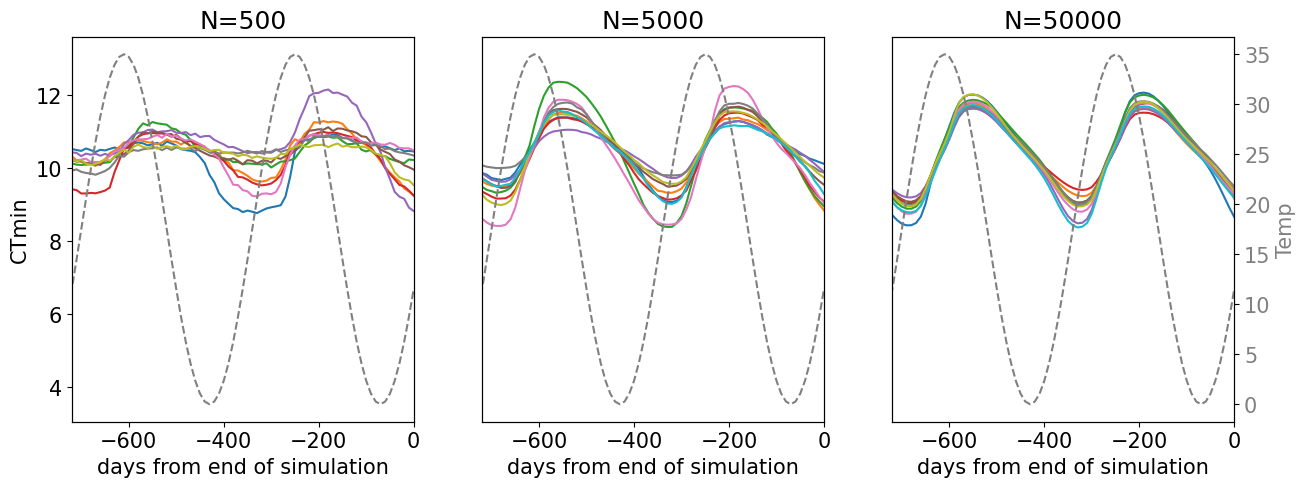

In [ ]:
# Figure S13

sine2_params = pd.read_csv("../scripts/01_prepare_input_parameters/sine2_params.csv")
Ns = sine2_params.N_POP.unique()

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
ax2 = [None, None, None]
def plot_sine2(row):
    if row.seed < 10:
        if os.path.isfile(f"{datadir}/{row.OUTNAME}.trees"):
            log = pd.read_csv(f"{datadir}/{row.OUTNAME}.txt")
            i = list(Ns).index(row.N_POP)
            ax.flat[i].plot(log.day - max(log.day), log.CTmin_mean)
        if row.seed == 0:
            ax2[i] = ax[i].twinx()
            ax2[i].plot(log.day - max(log.day), log.Temp, color="grey", linestyle="--")
            ax2[i].tick_params(axis='y', labelcolor='grey')
    
sine2_params.apply(plot_sine2, axis=1)

for i, N in enumerate(Ns):
    ax.flat[i].set_xlim((-720, 0))
    # ax.flat[i].set_ylim((2, 3.8))
    ax[i].set_xlabel("days from end of simulation")
    ax[i].set_title(f"N={N}")
    if i != 0:
        ax[i].set_yticks([])
    if i != 2:
        ax2[i].set_yticks([])
ax[0].set_ylabel('CTmin')
ax2[2].set_ylabel('Temp', color='grey')
fig.savefig("../figures/changing_N.png", bbox_inches='tight')

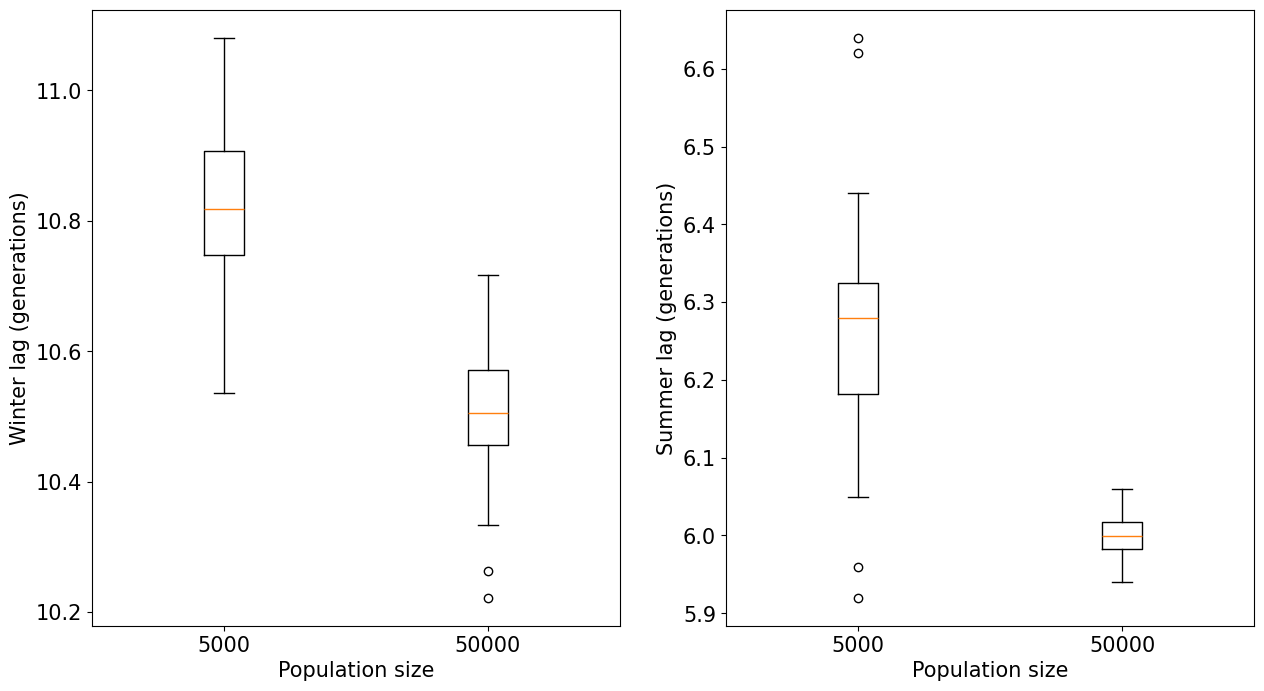

In [ ]:
# Figure S14
sine2_params = pd.read_csv("../scripts/01_prepare_input_parameters/sine2_params.csv")
Ns = [5000, 50_000]
winter_lags = {5000: [], 50_000: []}
summer_lags = {5000: [], 50_000: []}

def measure_lag(row):
    if row.N_POP in Ns:
        log = pd.read_csv(f"{datadir}/{row.OUTNAME}.txt")
        log2 = log[log.cycle - max(log.cycle) > -360 * 10]
        Temp_maxs = scipy.signal.find_peaks(log2.Temp, distance = 30)[0]

        CTmin_maxs = scipy.signal.find_peaks(log2.CTmin_mean, distance = 30, height=log2.CTmin_mean.mean())[0]

        Temp_mins = scipy.signal.find_peaks(-log2.Temp, distance = 30)[0]
        CTmin_mins = scipy.signal.find_peaks(-log2.CTmin_mean, distance = 30, height=-log2.CTmin_mean.mean())[0]
        CTmin_lag_winter = np.mean(CTmin_mins[1:] - Temp_mins[:-1])
        CTmin_lag_summer = np.mean(CTmin_maxs - Temp_maxs)
        winter_lags[row.N_POP].append(CTmin_lag_winter)
        summer_lags[row.N_POP].append(CTmin_lag_summer)


sine2_params.apply(measure_lag, axis=1)
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15, 8))
ax[0].boxplot(winter_lags.values(), tick_labels=winter_lags.keys())
ax[0].set_ylabel('Winter lag (generations)')
ax[0].set_xlabel('Population size')
ax[1].boxplot(summer_lags.values(), tick_labels=summer_lags.keys())
ax[1].set_ylabel('Summer lag (generations)')
ax[1].set_xlabel("Population size")
fig.savefig("../figures/changing_N_lag.png", bbox_inches='tight')

B=23.1492
CTmin=1.81624
B summer=23.3291
CTmin=2.23055


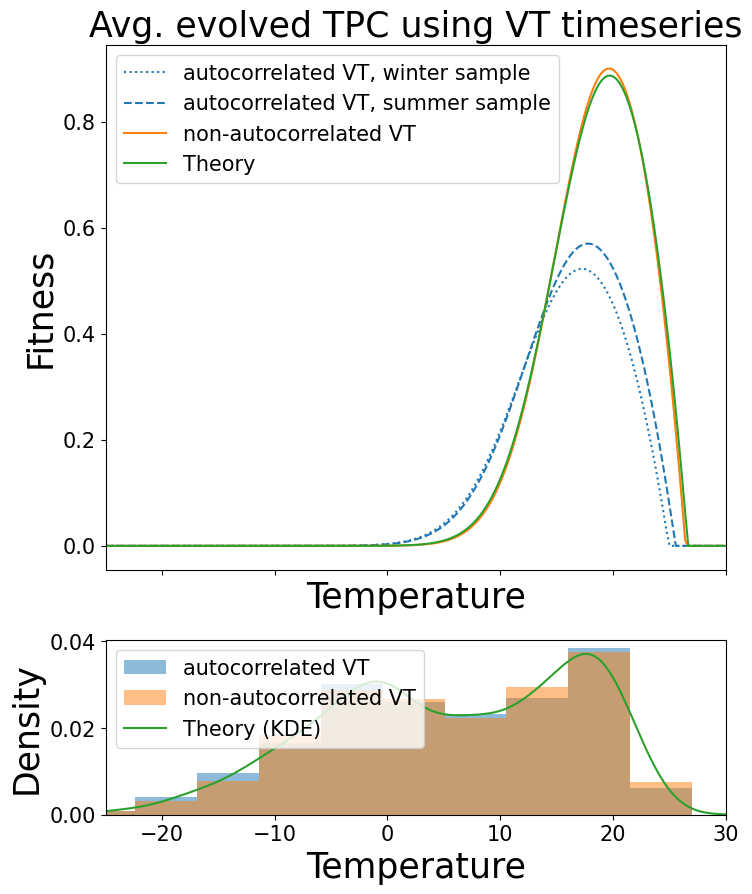

In [ ]:
# Figure S15
# prepare theoretical prediction
# First import time-series data and fit a Gaussian KDE
vt_temp = pd.read_csv("../slim/VT_weather.txt").T2M
kernel = scipy.stats.gaussian_kde(vt_temp)

# Modify w_TPC functions to predict optimal TPC from an arbitrary kernel
def expected_w_TPC_temp_series(temp_series, CTmin, B):
    '''
    Expected TPC given temperature list, assuming reproductive output per day after heat damage is zero (no-recovery model).
    The expected value is derived in the SI of the manuscript. 
    In short, it involves calculating probability that the temperature stays under lethal limit for various number of days.
    '''
    # update params to match the simulation
    tpc_object.num_days_per_gen = 21 
    nr = tpc_object.num_days_per_gen
    tpc_object.CTmin_critical = 1.5
    tpc_object.B_critical = 30

    CTmin_array = np.array(CTmin, ndmin=1)
    B_array = np.array(B, ndmin=1)
    
    kernel = scipy.stats.gaussian_kde(temp_series)
    CTmin_grid, B_grid = np.meshgrid(CTmin_array, B_array)
    output = np.zeros(CTmin_grid.shape)
    for i in range(output.shape[0]):
        for j in range(output.shape[1]):
            CTmin = CTmin_grid[i,j]
            B = B_grid[i,j]
            CTmax = CTmin + B
            fun = lambda T: tpc_object.w_TPC(T=T, CTmin=CTmin, B=B) * kernel.pdf(T)
            integral, err = scipy.integrate.quad(fun, CTmin, CTmax)
            r = kernel.integrate_box_1d(min(temp_series) - 10, CTmax)
            if (1 - r) < np.finfo(np.float64).tiny:
                C = 1
            else:
                C = (1 - nr * r ** (nr - 1) + (-1 + nr) * r ** nr) / (nr * (1 - r)) + r ** (nr - 1)
            output[i,j] = C * integral
    return output

def optimize_expected_w_TPC_temp_series(temp_series, CTmin0, B0):
    '''
    Find optimal CTmin and B that maximize expected w_TPC using no-recovery model.
    CTmin0 and B0 are initial guess
    '''
    B_tiny = 1e-3
    def objective(params):
        CTmin, B = params
        expected_w_TPC = expected_w_TPC_temp_series(temp_series=temp_series, B=B, CTmin=CTmin)
        return -expected_w_TPC
    bnds = ((None, None), (B_tiny, None))
    results = scipy.optimize.minimize(objective, [CTmin0, B0], method='L-BFGS-B', bounds=bnds)
    return results.x
CTmin_opt, B_opt = optimize_expected_w_TPC_temp_series(vt_temp, 5, 10)


log_new = pd.read_csv(f"{datadir}VT_autocorrelated_0.txt")
log2 = pd.read_csv(f"{datadir}VT_scrambled.txt")
Tlist = np.linspace(-25, 30, 200)
fig, ax = plt.subplots(figsize=(8,10), nrows=2, ncols=1, height_ratios=[3, 1], sharex=True)
# number of generations before the end of simulation to sample
sample1=32
sample2=23
ax[0].plot(Tlist, 
    tpc_object.w_TPC(B=np.array(log_new.B_mean)[-1-sample1], 
        CTmin=np.array(log_new.CTmin_mean)[-1-sample1], 
        T=Tlist),
    color='tab:blue',
    linestyle='dotted',
    label=f'autocorrelated VT, winter sample')
print(f"B={np.array(log_new.B_mean)[-1-sample1]}")
print(f"CTmin={np.array(log_new.CTmin_mean)[-1-sample1]}")
ax[0].plot(Tlist, 
    tpc_object.w_TPC(B=np.array(log_new.B_mean)[-1-sample2], 
        CTmin=np.array(log_new.CTmin_mean)[-1-sample2], 
        T=Tlist),
    linestyle='--',
    label=f'autocorrelated VT, summer sample')

print(f"B summer={np.array(log_new.B_mean)[-1-sample2]}")
print(f"CTmin={np.array(log_new.CTmin_mean)[-1-sample2]}")
ax[0].plot(Tlist, 
    tpc_object.w_TPC(B=np.array(log2.B_mean)[-1], 
        CTmin=np.array(log2.CTmin_mean)[-1], 
        T=Tlist),
    label='non-autocorrelated VT')
ax[0].plot(Tlist, 
    tpc_object.w_TPC(B=B_opt, CTmin=CTmin_opt, T=Tlist), 
    label='Theory')
ax[0].set_xlim((Tlist[0], Tlist[-1]))
ax[0].set_title("Avg. evolved TPC using VT timeseries", fontsize=25)
ax[0].set_xlabel("Temperature", fontsize=25)
ax[0].set_ylabel("Fitness", fontsize=25)
ax[0].legend()
ax[1].hist(log_new.Temp, density=True, label='autocorrelated VT', alpha=0.5)
ax[1].hist(log2.Temp, density=True, label='non-autocorrelated VT', alpha=0.5)
ax[1].plot(Tlist, kernel.pdf(Tlist), label='Theory (KDE)')
ax[1].set_xlabel("Temperature", fontsize=25)
ax[1].set_ylabel("Density", fontsize=25)
ax[1].set_xlim((Tlist[0], Tlist[-1]))
ax[1].legend()
fig.savefig('../figures/vt-autocorrelation.pdf', bbox_inches='tight')

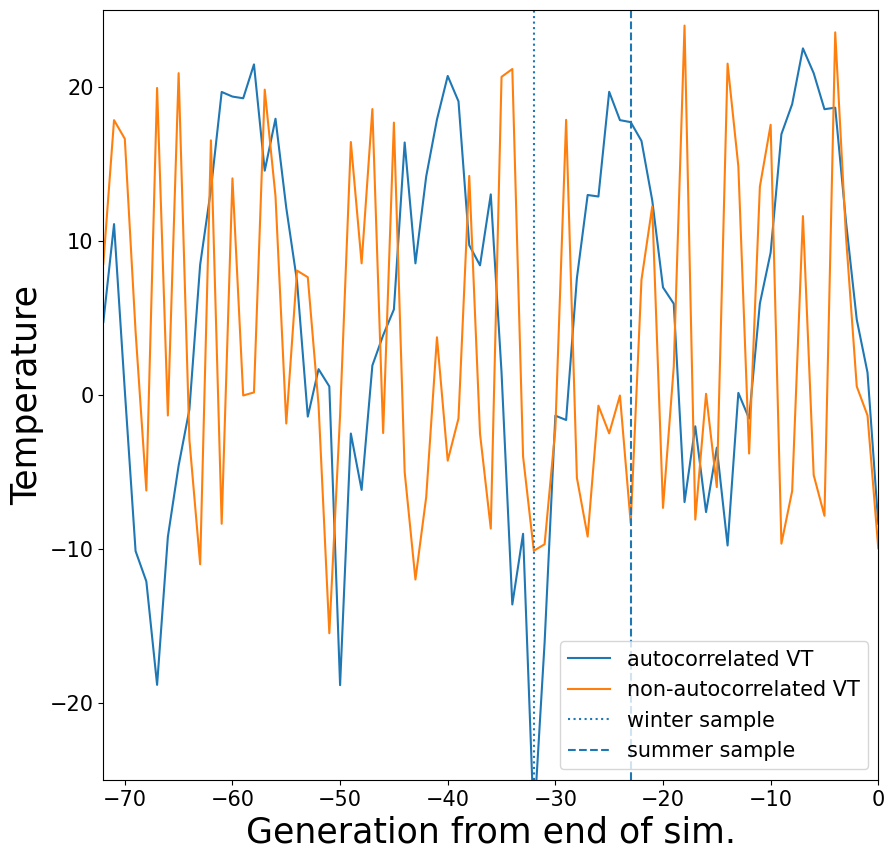

In [ ]:
# Figure S16
fig, ax = plt.subplots(figsize=(10,10))

ax.plot(log_new.cycle -max(log_new.cycle), log_new.Temp, label='autocorrelated VT')
ax.plot(log2.cycle -max(log2.cycle), log2.Temp, label='non-autocorrelated VT')
ymin=-25
ymax=25
ax.vlines(-sample1, ymin=ymin, ymax=ymax, linestyle='dotted', label='winter sample')
ax.vlines(-sample2, ymin=ymin, ymax=ymax, linestyle='--', label='summer sample')
ax.set_ylim((ymin, ymax))
ax.set_xlim((-72,0))
ax.set_xlabel("Generation from end of sim.", fontsize=25)
ax.set_ylabel("Temperature", fontsize=25)
ax.legend()
fig.savefig("../figures/vt-autocorrelation-timeseries.pdf", bbox_inches='tight')

In [ ]:
# Identifying peaks and valleys of TPC parameters, and quantifying winter vs. summer lags
# (See Results/Adaptive tracking to sinusolidal temperature)

log = pd.read_csv(f"{datadir}sine_test_CTmin_critical_0_B_critical_20.txt")

log['day_from_end_of_sim'] = log.day - max(log.day)
log2 = log[log.day_from_end_of_sim > - 3601]

Temp_maxs = scipy.signal.find_peaks(log2.Temp, distance = 30)[0]
CTmin_maxs = scipy.signal.find_peaks(log2.CTmin_mean, distance = 30, height=log2.CTmin_mean.mean())[0]
CTmax_maxs = scipy.signal.find_peaks(log2.CTmax_mean, distance = 30, height=log2.CTmax_mean.mean())[0]
Topt_maxs = scipy.signal.find_peaks(log2.Topt_mean, distance = 30, height=log2.Topt_mean.mean())[0]
B_maxs = scipy.signal.find_peaks(log2.B_mean, distance = 30, height=log2.B_mean.mean())[0]


Temp_mins = scipy.signal.find_peaks(-log2.Temp, distance = 30)[0]
CTmin_mins = scipy.signal.find_peaks(-log2.CTmin_mean, distance = 30, height=-log2.CTmin_mean.mean())[0]
CTmax_mins = scipy.signal.find_peaks(-log2.CTmax_mean, distance = 30, height=-log2.CTmax_mean.mean())[0]
Topt_mins = scipy.signal.find_peaks(-log2.Topt_mean, distance = 30, height=-log2.Topt_mean.mean())[0]
B_mins = scipy.signal.find_peaks(-log2.B_mean, distance = 30, height=-log2.B_mean.mean())[0]

CTmin_annual_min_values = np.array(log2.CTmin_mean.reset_index(drop=True).loc[CTmin_mins])
CTmin_annual_max_values = np.array(log2.CTmin_mean.reset_index(drop=True).loc[CTmin_maxs])
print(f"CTmin minimized {np.mean(CTmin_mins[1:] - Temp_mins[:-1])} generations after the lowest temperature")
print(f"CTmin minimized {np.mean(np.array(log2.day)[CTmin_mins[1:]] - np.array(log2.day)[Temp_mins[:-1]])} days after the lowest temperature")

print(f"CTmin peaks {np.mean(CTmin_maxs - Temp_maxs)} generations after the highest temperature")
print(f"CTmin peaks {np.mean(np.array(log2.day)[CTmin_maxs] - np.array(log2.day)[Temp_maxs])} days after the lowest temperature")

print(f"average yearly amplitude of CTmin is {np.mean(CTmin_annual_max_values - CTmin_annual_min_values)}")

print(f"CTmax minimized {np.mean(CTmax_mins[1:] - Temp_mins[:-1])} generations after the lowest temperature")
print(f"CTmax peaks {np.mean(CTmax_maxs - Temp_maxs)} generations after the highest temperature")

print(f"Topt minimized {np.mean(Topt_mins[1:] - Temp_mins[:-1])} generations after the lowest temperature")
print(f"Topt peaks {np.mean(Topt_maxs - Temp_maxs)} generations after the highest temperature")

print(f"B minimized {np.mean(B_mins[1:] - Temp_mins[:-1])} generations after the lowest temperature")
print(f"B peaks {np.mean(B_maxs - Temp_maxs)} generations after the highest temperature")

CTmin minimized 11.0 generations after the lowest temperature
CTmin minimized 110.0 days after the lowest temperature
CTmin peaks 6.3 generations after the highest temperature
CTmin peaks 63.0 days after the lowest temperature
average yearly amplitude of CTmin is 2.3805810000000003
CTmax minimized 12.0 generations after the lowest temperature
CTmax peaks 5.1 generations after the highest temperature
Topt minimized 11.88888888888889 generations after the lowest temperature
Topt peaks 5.3 generations after the highest temperature
B minimized 13.222222222222221 generations after the lowest temperature
B peaks 3.6 generations after the highest temperature


In [ ]:
# Table S1
params = pd.read_csv("../scripts/01_prepare_input_parameters/gaussian_params.csv")
params = params[(params.STDEV_TEMP < 10)]
params_sub = params[(params.seed == 29)]
params_sub = params_sub.sort_values(by=['MEAN_TEMP', 'STDEV_TEMP']).reset_index(drop=True)
def QTN_stats(row):
    '''
    Find the number of segregating QTN's mutations at the end of the simulation and the mean and standard deviation of effect sizes
    '''
    ts = tskit.load(f"{datadir}{row.OUTNAME}.trees")
    QTN_Bs = []
    QTN_CTmins = []
    for mut in ts.mutations():
        for submut in mut.metadata['mutation_list']:
            if submut['mutation_type'] == 2:
                QTN_Bs.append(submut['selection_coeff'])
            else:
                QTN_CTmins.append(submut['selection_coeff'])
    return (row.MEAN_TEMP, row.STDEV_TEMP, len(QTN_Bs), np.mean(QTN_Bs), np.std(QTN_Bs), len(QTN_CTmins), np.mean(QTN_CTmins), np.std(QTN_CTmins))
QTN_df = params_sub.apply(QTN_stats, axis=1, result_type='expand')
QTN_df.columns = ['mean(T)', 'sd(T)', 'num_QTN_Bs', 'mean(QTN_B_effect_size)', 'std(QTN_B_effect_size)', 'num_QTN_CTmins', 'mean(QTN_CTmin_effect_size)', 'std(QTN_CTmin_effect_size)']
QTN_df['mean(T)'] = QTN_df['mean(T)'].astype(int)
QTN_df['sd(T)'] = QTN_df['sd(T)'].astype(int)
QTN_df['num_QTN_Bs'] = QTN_df['num_QTN_Bs'].astype(int)
QTN_df['num_QTN_CTmins'] = QTN_df['num_QTN_CTmins'].astype(int)
print(QTN_df)
# print(QTN_df.to_latex())

   mean(T)  sd(T)  num_QTN_Bs  mean(QTN_B_effect_size)  \
0        5      1         408                -0.029892   
1        5      3         422                -0.017649   
2       20      1         497                -0.007703   
3       20      3         521                -0.004768   
4       35      1         389                -0.012341   
5       35      3         299                -0.006246   

   std(QTN_B_effect_size)  num_QTN_CTmins  mean(QTN_CTmin_effect_size)  \
0                0.208303             348                    -0.018062   
1                0.218915             358                    -0.011388   
2                0.215919             435                    -0.017340   
3                0.203025             454                    -0.003597   
4                0.189480             366                     0.026760   
5                0.191943             305                     0.033317   

   std(QTN_CTmin_effect_size)  
0                    0.181288  
1         

In [ ]:
# Table S2
from scipy.signal import lfilter
# Function for finding equilibration time.
# We fine when fitness has gotten 99% close to the final value for the first time, using the smoothed out fitness curve. 
def fit_t_equil(row):
    log = pd.read_csv(f"{datadir}{row.OUTNAME}.txt", sep=',')
    log = log.loc[log.cycle > 5000].reset_index(drop=True)
    try:
        
        if log.cycle.iloc[-1] == row.RUNTIME_IF_NO_EXTERNAL_TEMP_DATA:
            # Smooth the mean fitness curve, find where the smoothed fitness becomes 99% close to the final fitness value
            n = 10             # larger n gives smoother curves
            b = [1.0 / n] * n  # numerator coefficients
            a = 1              # denominator coefficient
            y_lf = lfilter(b, a, np.array(log.fitness_mean))
            t_equil = None
            for index2, row2 in log.iterrows():
                if (y_lf[index2] - y_lf[0] > 0.99 * (y_lf[-1] - y_lf[0])) and (t_equil == None):
                    t_equil = row2.cycle
                    t_equil = round(t_equil)
            
            fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10,10))
            ax.plot(log.cycle, log.fitness_mean)
            ax.vlines(t_equil, ymin=log.fitness_mean.min(), ymax=log.fitness_mean.max())
            ax.set_xlabel("generation")
            ax.set_ylabel("fitness")
            fig.savefig(f"{datadir}t_equil_{row.OUTNAME}.png")
            plt.close()
            return t_equil

    except IndexError:
        print("log file empty")
params = pd.read_csv("../scripts/01_prepare_input_parameters/gaussian_params.csv")
params = params[params.STDEV_TEMP<10]
# Attach the equilibrium time to the params dataframe
params['t_equil'] = params.apply(fit_t_equil, axis=1)
t_equil_df = params.groupby(['MEAN_TEMP', 'STDEV_TEMP', 'B_default', 'CTmin_default']).agg({
    't_equil': ['mean', 'std']
}).round()
print(t_equil_df['t_equil'])

                                                 mean     std
MEAN_TEMP STDEV_TEMP B_default CTmin_default                 
5         1          31        5               5880.0   181.0
          3          31        5               5630.0   164.0
20        1          31        5               6044.0   214.0
          3          31        5               5494.0    94.0
35        1          31        5              15908.0  1295.0
          3          31        5              23593.0  3797.0


In [ ]:
# Table S3
def classify_final_TPCs(row):
    # threshold w_component when parameter = parameter_critical + Delta_parameter (replace parameter with CTmin, CTmax or B)
    threshold = 0.5
    B_and_CTmin = pd.read_csv(f"{datadir}gaussian_MEAN_TEMP_{row.MEAN_TEMP}_STDEV_TEMP_{row.STDEV_TEMP}_seed_{row.seed}.csv", engine='python', sep=', ')
    Bs_final = np.array(B_and_CTmin.B)
    CTmins_final = np.array(B_and_CTmin.CTmin)

    n_green = 0
    n_blue = 0
    n_red = 0
    n_grey = 0
    n_others = 0
    for B, CTmin in zip(Bs_final, CTmins_final):
        w_CTmin = tpc_object.w_CTmin(CTmin=CTmin)
        w_B = tpc_object.w_B(B=B)
        CTmax = CTmin + B
        w_CTmax = tpc_object.w_CTmax(CTmax=CTmax)
        if (w_B <= threshold) and (w_CTmin > threshold) and (w_CTmax > threshold):
            # Too generalist
            n_green += 1
        elif (w_CTmin <= threshold) and (w_B > threshold) and (w_CTmax > threshold):
            # Too much cold adaptation
            n_blue += 1
        elif (w_B > threshold) and (w_CTmin > threshold) and (w_CTmax <= threshold):
            # Too much heat adaptation
            n_red += 1
        elif (np.array([w_B, w_CTmin, w_CTmax]) > threshold).all():
            # not limited by any of 3 physiological constraints
            n_grey += 1
        else:
            # other kinds
            print(f"mean temperature={row.MEAN_TEMP}, std={row.STDEV_TEMP}")
            print(f"w_B={w_B}, w_CTmin={w_CTmin}, w_CTmax={w_CTmax}")
            n_others += 1
    n_total = n_green + n_blue + n_red + n_grey + n_others
    ratio_green = n_green / n_total
    ratio_blue = n_blue / n_total
    ratio_red = n_red / n_total
    ratio_grey = n_grey / n_total
    ratio_others = n_others / n_total

    return (row.MEAN_TEMP, row.STDEV_TEMP, row.seed, ratio_green, ratio_blue, ratio_red, ratio_grey, ratio_others)

final_tpc_classified_df = params.apply(classify_final_TPCs, axis=1, result_type='expand')
final_tpc_classified_df.columns = ['mean_T', 'std_T', 'seed', 'ratio_green', 'ratio_blue', 'ratio_red', 'ratio_grey', 'ratio_others']
summary_df = final_tpc_classified_df.groupby(['mean_T', 'std_T']).agg({
    'ratio_blue': ['mean', 'std'],
    'ratio_red': ['mean', 'std'],
})
print(summary_df)
# print(summary_df.to_latex())

             ratio_blue           ratio_red          
                   mean       std      mean       std
mean_T std_T                                         
5.0    1.0     0.545561  0.015528  0.000000  0.000000
       3.0     0.518858  0.018590  0.000000  0.000000
20.0   1.0     0.000000  0.000000  0.000000  0.000000
       3.0     0.000000  0.000000  0.000000  0.000000
35.0   1.0     0.000000  0.000000  0.055224  0.003382
       3.0     0.000000  0.000000  0.129868  0.004674


In [ ]:
# Save path to all data files needed for this script
datadir = os.path.abspath("../data")
needed = sorted(p for p in _accessed if p.startswith(datadir))
with open("../data/data_for_SI_figures.txt", "w") as f:
    f.write("\n".join(os.path.relpath(p, datadir) for p in needed))